# Thesis Figures Generator

## Macro-Aviation-Tourism Demand Modelling and Forecasting for Poland

**Author:** Diego Marrero Ferrera  
**Repository:** [GitHub — Macro-Aviation-Tourism-Modeling](https://github.com/DieGodMF4/Macro-Aviation-Tourism-Modeling)  
**Last updated:** 2026-05

---

### Purpose

This notebook generates the figures of the thesis memoir that are **not** produced by the analysis notebooks (NB00–NB09). It produces visualisations that integrate data from multiple raw datasets specifically for the thesis manuscript and that do not belong logically to any individual analysis stage.

Figures produced here:

- **Figure 1.1** — Tourism contribution to GDP across European countries (WTTC data).
- **Figure 1.2** — Parallel growth of air passengers and GDP per capita of Poland since EU accession (2004–2024).
- **Figure 2.1** — Polish air traffic with LCC penetration and origin-market share (combined panel).

All figures follow the project's plot conventions (paths, palette, COVID shading, savefig).

## 0. Environment & Configuration

In [2]:
import pandas as pd
import numpy as np
import os
import warnings
import re

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

# --- PLOT SETTINGS (matching project convention) ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
    'savefig.bbox': 'tight',
    'savefig.dpi': 200,
    'savefig.facecolor': 'white',
})

# Consistent palette across the project
COLORS = {
    'primary':   '#2c3e50',
    'secondary': '#e74c3c',
    'accent1':   '#3498db',
    'accent2':   '#2ecc71',
    'accent3':   '#f39c12',
    'accent4':   '#9b59b6',
    'gray':      '#95a5a6',
    'covid':     '#e74c3c',
}

COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2021-06-30')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Environment ready.')

Environment ready.


In [3]:
# --- PROJECT PATHS ---
# This notebook lives at: /documentation_es/scripts-generate-figs/nb-figures.ipynb
# Therefore data/raw is two levels up.
DATA_RAW  = os.path.join('..', '..', 'data', 'raw')
FIG_DIR   = os.path.join('..', 'figures-memoria')
os.makedirs(FIG_DIR, exist_ok=True)

# --- FILE CATALOGUE (mirroring NB01's structure) ---
FILES = {
    # Transport
    'avia_seats':    os.path.join(DATA_RAW, 'transport',
                        'avia_tf_aca__seats-flights-pass-PL-2010-.csv'),
    'avia_pax':      os.path.join(DATA_RAW, 'transport',
                        'avia_paoc__passengers-countries.csv'),
    'avia_airports': os.path.join(DATA_RAW, 'transport',
                        'avia_tf_apal_passengers_airports_PL-2003-.csv'),
    # Economic
    'gdp_real':      os.path.join(DATA_RAW, 'economic',
                        'namq_10_gdp__real-gdp-CLV-2010.csv'),
    'gdp_nominal':   os.path.join(DATA_RAW, 'economic',
                        'namq_10_gdp__market_prices.csv'),
    'hicp_midx':     os.path.join(DATA_RAW, 'economic',
                      'prc_hicp_midx__relevant-countries-2011-.csv'),
    # UK-specific from ONS
    'hicp_uk':    os.path.join(DATA_RAW, 'uk_specific',
                      'ons_hicp_uk_d7bt.csv'),
    'gdp_uk':     os.path.join(DATA_RAW, 'uk_specific',
                      'ons_gdp_uk_abmi.csv'),
    'pop_uk':     os.path.join(DATA_RAW, 'uk_specific',
                      'ons_pop_uk.csv'),
    # Demographic
    'population':    os.path.join(DATA_RAW, 'demographic',
                        'demo_pjan__population-eur-990-25.csv'),
}

print('File verification:')
for name, path in FILES.items():
    tag = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{tag}] {name}: {os.path.basename(path)}')

File verification:
  [OK] avia_seats: avia_tf_aca__seats-flights-pass-PL-2010-.csv
  [OK] avia_pax: avia_paoc__passengers-countries.csv
  [OK] avia_airports: avia_tf_apal_passengers_airports_PL-2003-.csv
  [OK] gdp_real: namq_10_gdp__real-gdp-CLV-2010.csv
  [OK] gdp_nominal: namq_10_gdp__market_prices.csv
  [OK] hicp_midx: prc_hicp_midx__relevant-countries-2011-.csv
  [OK] hicp_uk: ons_hicp_uk_d7bt.csv
  [OK] gdp_uk: ons_gdp_uk_abmi.csv
  [OK] pop_uk: ons_pop_uk.csv
  [OK] population: demo_pjan__population-eur-990-25.csv


In [4]:
# --- HELPER FUNCTIONS (matching NB01 conventions) ---
NAME_TO_CODE = {
    'Austria': 'AT', 'Croatia': 'HR', 'Czechia': 'CZ',
    'France': 'FR', 'Germany': 'DE', 'Greece': 'EL',
    'Hungary': 'HU', 'Italy': 'IT', 'Netherlands': 'NL',
    'Poland': 'PL', 'Spain': 'ES', 'Sweden': 'SE',
    'United Kingdom': 'UK', 'United States': 'US',
    'European Union - 27 countries (from 2020)': 'EU27',
    'Euro area – 20 countries (from 2023)': 'EA20',
}


def load_eurostat(path, parse_dates=True):
    """Load an Eurostat CSV and parse TIME_PERIOD to datetime if requested."""
    df = pd.read_csv(path)
    if parse_dates and 'TIME_PERIOD' in df.columns:
        tp = df['TIME_PERIOD'].astype(str)
        if tp.str.match(r'^\d{4}-\d{2}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y-%m')
        elif tp.str.match(r'^\d{4}-Q\d$').all():
            df['date'] = pd.PeriodIndex(tp, freq='Q').to_timestamp()
        elif tp.str.match(r'^\d{4}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y')
        else:
            df['date'] = pd.to_datetime(tp, errors='coerce')
    return df

def load_ons(path, frequency='monthly'):
    """
    Load an ONS time series CSV.
    ONS files mix annual, quarterly and monthly rows in one file.
    Date formats: 'YYYY' (annual), 'YYYY Q#' (quarterly), 'YYYY MMM' (monthly).
    """
    df = pd.read_csv(path, header=None, names=['date_str', 'value'],
                     skiprows=8, dtype={'date_str': str, 'value': str})
    df = df.dropna(subset=['date_str', 'value'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna(subset=['value'])

    pat_annual    = re.compile(r'^\d{4}$')
    pat_quarterly = re.compile(r'^\d{4}\s*Q[1-4]$')
    pat_monthly   = re.compile(r'^\d{4}\s+[A-Z]{3}$')

    if frequency == 'annual':
        mask = df['date_str'].str.match(pat_annual)
        sub = df[mask].copy()
        sub['date'] = pd.to_datetime(sub['date_str'], format='%Y')
    elif frequency == 'quarterly':
        mask = df['date_str'].str.match(pat_quarterly)
        sub = df[mask].copy()
        sub['date'] = pd.PeriodIndex(
            sub['date_str'].str.replace(' ', ''), freq='Q'
        ).to_timestamp()
    elif frequency == 'monthly':
        mask = df['date_str'].str.match(pat_monthly)
        sub = df[mask].copy()
        sub['date'] = pd.to_datetime(sub['date_str'], format='%Y %b')
    else:
        raise ValueError(f'Unknown frequency: {frequency}')

    return sub.set_index('date')['value'].sort_index()

def add_geo_code(df):
    if 'geo' in df.columns:
        df['iso'] = df['geo'].map(NAME_TO_CODE)
    return df


def covid_shade(ax):
    ax.axvspan(COVID_START, COVID_END, alpha=0.10, color=COLORS['covid'],
               label='COVID-19 period')


def format_year_axis(ax, interval=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=200, bbox_inches='tight')


print('Helper functions defined.')

Helper functions defined.


---

## Figure 1.1 — Tourism Contribution to GDP by European Country (WTTC 2024)

Sourced from the WTTC *Travel & Tourism Economic Impact* 2024 release. The values represent total contribution of travel and tourism to each country's GDP as a percentage. Since the WTTC data is not part of the project's raw data files, the values are entered manually as constants and the figure compares Poland with a selection of representative European tourism economies.

**Source:** WTTC (2025). *Travel & Tourism Economic Impact 2025.* World Travel & Tourism Council. https://wttc.org/

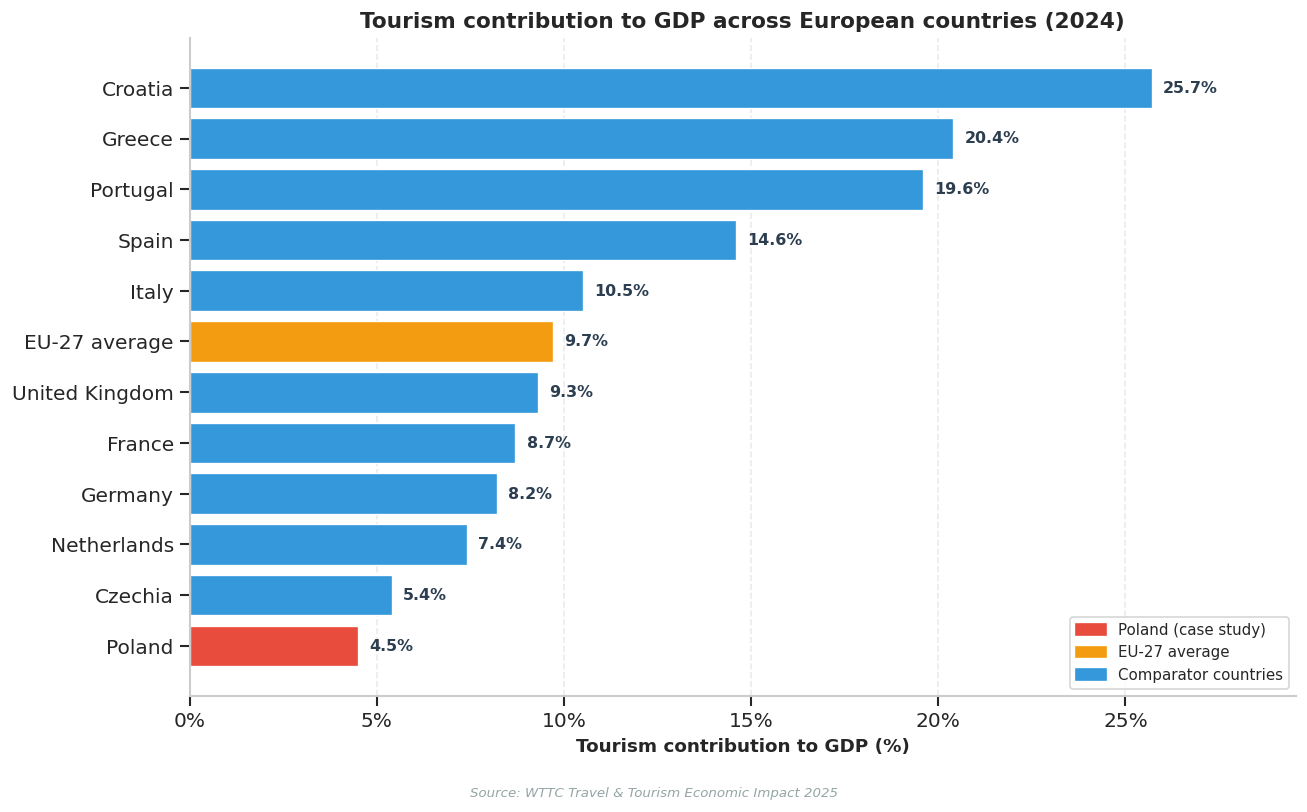

In [5]:
# WTTC 2024 — total contribution of travel & tourism to GDP, % of country GDP
# Values are approximate and should be verified against the latest WTTC report before final submission
wttc_data = pd.DataFrame([
    ('Croatia',     25.7, 'HR'),
    ('Greece',      20.4, 'EL'),
    ('Portugal',    19.6, 'PT'),
    ('Spain',       14.6, 'ES'),
    ('Italy',       10.5, 'IT'),
    ('EU-27 average', 9.7, 'EU27'),
    ('France',       8.7, 'FR'),
    ('Germany',      8.2, 'DE'),
    ('United Kingdom', 9.3, 'UK'),
    ('Netherlands',  7.4, 'NL'),
    ('Czechia',      5.4, 'CZ'),
    ('Poland',       4.5, 'PL'),
], columns=['country', 'gdp_share', 'iso'])
wttc_data = wttc_data.sort_values('gdp_share', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6.5))

# Colour-code: Poland in red, EU-27 average in orange, others in blue
bar_colors = []
for c in wttc_data['country']:
    if c == 'Poland':
        bar_colors.append(COLORS['secondary'])
    elif c == 'EU-27 average':
        bar_colors.append(COLORS['accent3'])
    else:
        bar_colors.append(COLORS['accent1'])

bars = ax.barh(wttc_data['country'], wttc_data['gdp_share'],
                color=bar_colors, edgecolor='white', linewidth=0.8)

# Value labels on each bar
for bar, val in zip(bars, wttc_data['gdp_share']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%',
             va='center', fontsize=9.5, fontweight='bold',
             color=COLORS['primary'])

ax.set_xlabel('Tourism contribution to GDP (%)', fontweight='bold')
ax.set_title('Tourism contribution to GDP across European countries (2024)',
              fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlim(0, max(wttc_data['gdp_share']) * 1.15)
ax.grid(axis='y', alpha=0)
ax.grid(axis='x', alpha=0.4)

# Legend with custom patches
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=COLORS['secondary'], label='Poland (case study)'),
    Patch(color=COLORS['accent3'],   label='EU-27 average'),
    Patch(color=COLORS['accent1'],   label='Comparator countries'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=True)

# Footer with source
fig.text(0.5, -0.03,
         'Source: WTTC Travel & Tourism Economic Impact 2025',
         ha='center', fontsize=8, style='italic', color=COLORS['gray'])

plt.tight_layout()
savefig('fig_1_1_tourism_gdp_share.png')
plt.show()

---

## Figure 1.2 — Parallel Growth of Air Connectivity and GDP per Capita of Poland (2004–2024)

Double-axis chart showing the parallel evolution of two complementary indicators of Poland's economic and connectivity convergence since EU accession in 2004. The left axis tracks total air passengers at Polish airports; the right axis tracks GDP per capita relative to the EU-27 average. The chart highlights the COVID-19 disruption and the differentiated recovery.

**Data sources:**
- Passengers: Eurostat `avia_tf_apal` (passengers by airport, Poland).
- GDP and population: Eurostat `namq_10_gdp` (nominal GDP at market prices) and `demo_pjan` (population on 1 January).

In [6]:
# --- LOAD AND AGGREGATE PASSENGER DATA ---
pax = load_eurostat(FILES['avia_airports'])
print('avia_airports columns:', list(pax.columns))
print('Sample row:')
print(pax.head(2))

avia_airports columns: ['DATAFLOW', 'LAST UPDATE', 'freq', 'unit', 'tra_meas', 'airline', 'rep_airp', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS', 'date']
Sample row:
                  DATAFLOW        LAST UPDATE     freq       unit  \
0  ESTAT:AVIA_TF_APAL(1.0)  16/12/25 23:00:00  Monthly  Passenger   
1  ESTAT:AVIA_TF_APAL(1.0)  16/12/25 23:00:00  Monthly  Passenger   

             tra_meas       airline                      rep_airp TIME_PERIOD  \
0  Passengers carried  All airlines  BYDGOSZCZ/SZWEDEROWO airport     2008-01   
1  Passengers carried  All airlines  BYDGOSZCZ/SZWEDEROWO airport     2008-02   

   OBS_VALUE  OBS_FLAG  CONF_STATUS       date  
0      17441       NaN          NaN 2008-01-01  
1      15181       NaN          NaN 2008-02-01  


In [7]:
# Aggregate passengers annually across all Polish airports
pax['year'] = pax['date'].dt.year
# Sum across all months and all airports — total annual passengers in Poland
pax_annual = pax.groupby('year')['OBS_VALUE'].sum()
pax_annual = pax_annual.loc[2004:2024]

print(f'Air passengers in Poland — annual totals (2004–2024):')
print(pax_annual.apply(lambda x: f'{x/1e6:.2f}M').to_string())

Air passengers in Poland — annual totals (2004–2024):
year
2004     6.09M
2005     7.08M
2006     8.12M
2007     9.35M
2008    11.24M
2009     9.92M
2010    10.61M
2011    11.25M
2012    11.89M
2013    12.92M
2014    14.63M
2015    16.41M
2016    18.42M
2017    21.67M
2018    24.56M
2019    25.95M
2020     7.56M
2021    10.74M
2022    21.20M
2023    38.55M
2024    58.89M


In [8]:
# --- LOAD REAL GDP OF POLAND (chain-linked volumes, 2010 reference) ---
gdp_real = load_eurostat(FILES['gdp_real'])

print('gdp_real shape:', gdp_real.shape)
print('Unique geo values:', sorted(gdp_real['geo'].unique()))
print('Unique unit values:', gdp_real['unit'].unique())
print('Unique na_item values:', gdp_real['na_item'].unique())
print('Unique s_adj values:', gdp_real['s_adj'].unique())

gdp_real shape: (1459, 12)
Unique geo values: ['Austria', 'Croatia', 'Czechia', 'France', 'Germany', 'Hungary', 'Italy', 'Netherlands', 'Poland', 'Spain', 'Sweden', 'United Kingdom']
Unique unit values: ['Chain linked volumes (2010), million euro']
Unique na_item values: ['Gross domestic product at market prices']
Unique s_adj values: ['Seasonally and calendar adjusted data']


In [9]:
# Filter Poland: real GDP at market prices, chain-linked volumes 2010, SCA.
# All four filter values exist as a single unique value in this dataset,
# so the filter is straightforward.
gdp_pol = gdp_real[
    (gdp_real['geo'] == 'Poland') &
    (gdp_real['na_item'] == 'Gross domestic product at market prices') &
    (gdp_real['unit'] == 'Chain linked volumes (2010), million euro') &
    (gdp_real['s_adj'] == 'Seasonally and calendar adjusted data')
].copy()

# Aggregate quarterly to annual (sum of four quarters = annual GDP)
gdp_pol['year'] = gdp_pol['date'].dt.year
gdp_pol_annual = gdp_pol.groupby('year')['OBS_VALUE'].sum()
# Restrict to the same year range as the passenger series
gdp_pol_annual = gdp_pol_annual.loc[2004:2024]

print(f'\nPoland real GDP, annual (chain-linked volumes 2010, million EUR):')
print(gdp_pol_annual.apply(lambda x: f'{x:>12,.0f}').to_string())


Poland real GDP, annual (chain-linked volumes 2010, million EUR):
year
2004         278,766
2005         287,712
2006         305,739
2007         326,486
2008         340,528
2009         348,825
2010         360,356
2011         379,244
2012         385,454
2013         388,114
2014         403,003
2015         420,489
2016         433,874
2017         456,530
2018         484,608
2019         506,502
2020         496,256
2021         530,198
2022         559,491
2023         560,295
2024         576,868


In [10]:
# --- LOAD POLAND POPULATION ---
pop = load_eurostat(FILES['population'])

pop_pol = pop[pop['geo'] == 'Poland'].copy()
# population dataset is annual (1 January reading)
pop_pol['year'] = pop_pol['date'].dt.year
pop_pol_annual = pop_pol.set_index('year')['OBS_VALUE']

# --- COMPUTE REAL GDP PER CAPITA (EUR, chain-linked 2010) ---
common_years = gdp_pol_annual.index.intersection(pop_pol_annual.index)
common_years = sorted([y for y in common_years if 2004 <= y <= 2024])

# GDP is in millions of EUR, population in persons.
# Multiply by 1e6 to express the per-capita figure in EUR per inhabitant per year.
gdppc_real = (gdp_pol_annual.loc[common_years] /
              pop_pol_annual.loc[common_years]) * 1e6

print(f'Poland real GDP per capita (EUR, chain-linked 2010 reference):')
print(gdppc_real.apply(lambda x: f'EUR {x:>10,.0f}').to_string())
print(f'\nKey figures:')
print(f'  2004: EUR {gdppc_real.iloc[0]:,.0f}')
print(f'  2024: EUR {gdppc_real.iloc[-1]:,.0f}')
print(f'  Growth multiplier: x{gdppc_real.iloc[-1]/gdppc_real.iloc[0]:.2f}')

Poland real GDP per capita (EUR, chain-linked 2010 reference):
year
2004    EUR      7,299
2005    EUR      7,537
2006    EUR      8,013
2007    EUR      8,563
2008    EUR      8,934
2009    EUR      9,147
2010    EUR      9,477
2011    EUR      9,964
2012    EUR     10,127
2013    EUR     10,197
2014    EUR     10,600
2015    EUR     11,064
2016    EUR     11,428
2017    EUR     12,022
2018    EUR     12,761
2019    EUR     13,339
2020    EUR     13,074
2021    EUR     14,301
2022    EUR     15,167
2023    EUR     15,245
2024    EUR     15,752

Key figures:
  2004: EUR 7,299
  2024: EUR 15,752
  Growth multiplier: x2.16


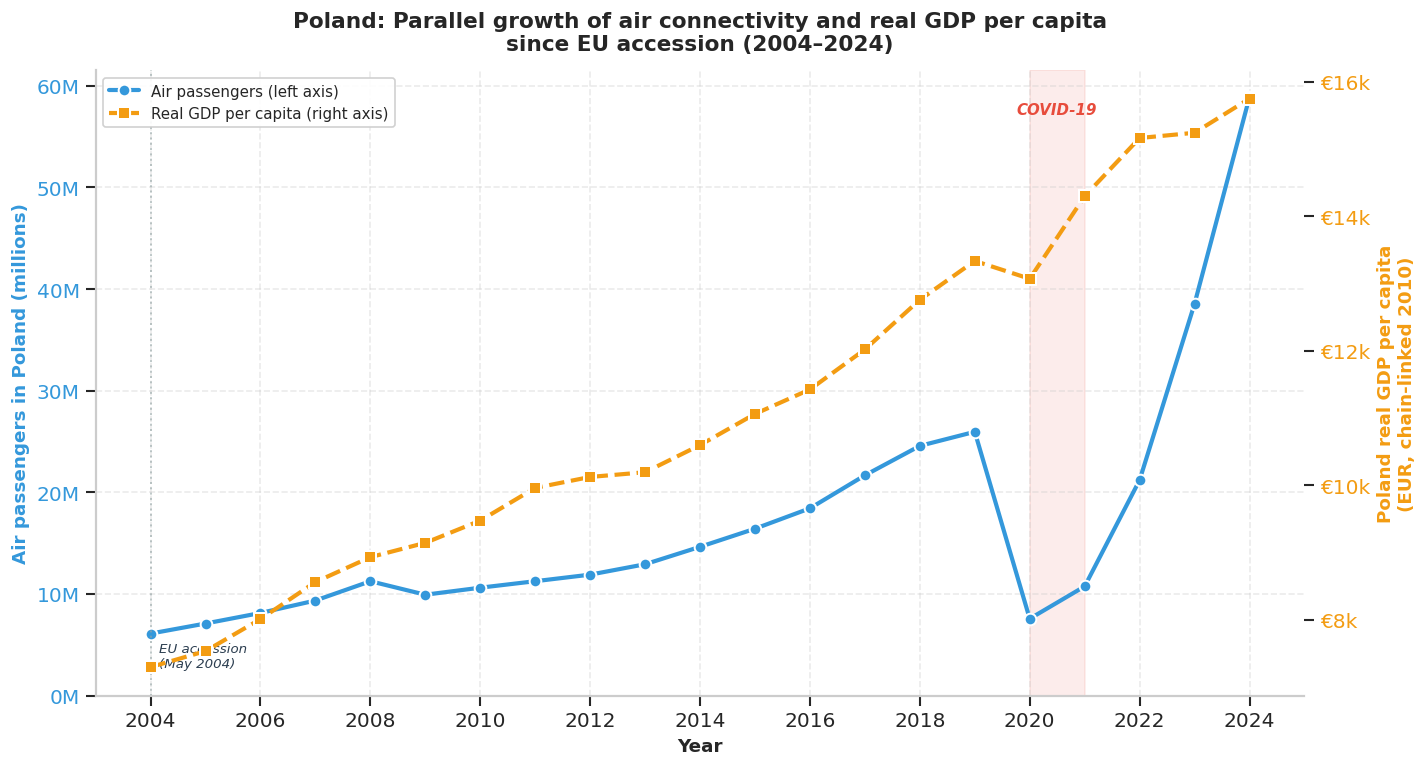

In [11]:
# --- BUILD THE FIGURE ---
fig, ax1 = plt.subplots(figsize=(12, 6.5))

# Left axis — Air passengers
color_pax = COLORS['accent1']
line1 = ax1.plot(pax_annual.index, pax_annual.values / 1e6,
                  marker='o', markersize=7, linewidth=2.5,
                  color=color_pax,
                  markeredgecolor='white', markeredgewidth=1.2,
                  label='Air passengers (left axis)')
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Air passengers in Poland (millions)',
                color=color_pax, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_pax)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:.0f}M'))
ax1.set_ylim(bottom=0)

# Right axis — Real GDP per capita
ax2 = ax1.twinx()
color_gdp = COLORS['accent3']
line2 = ax2.plot(gdppc_real.index, gdppc_real.values,
                  marker='s', markersize=7, linewidth=2.5, linestyle='--',
                  color=color_gdp,
                  markeredgecolor='white', markeredgewidth=1.2,
                  label='Real GDP per capita (right axis)')
ax2.set_ylabel('Poland real GDP per capita\n(EUR, chain-linked 2010)',
                color=color_gdp, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_gdp)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'€{x/1000:.0f}k'))
ax2.grid(False)
ax2.spines['top'].set_visible(False)

# Vertical reference: EU accession in May 2004
ax1.axvline(2004, color=COLORS['gray'], linestyle=':', linewidth=1.2, alpha=0.6)
ax1.text(2004.15, ax1.get_ylim()[1] * 0.04,
          'EU accession\n(May 2004)',
          fontsize=8, color=COLORS['primary'],
          style='italic', va='bottom')

# COVID-19 shading
ax1.axvspan(2020, 2021, color=COLORS['covid'], alpha=0.10, zorder=0)
ax1.text(2020.5, ax1.get_ylim()[1] * 0.93,
          'COVID-19',
          fontsize=9, color=COLORS['secondary'],
          ha='center', fontweight='bold', style='italic')

# Combined legend (both axes)
ax1.legend(line1 + line2,
            [l.get_label() for l in line1 + line2],
            loc='upper left', frameon=True, framealpha=0.9)

# X-axis: tick every 2 years
ax1.set_xticks(range(2004, 2025, 2))
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))

plt.title('Poland: Parallel growth of air connectivity and real GDP per capita\n'
           'since EU accession (2004–2024)',
           fontweight='bold', pad=12)
plt.tight_layout()
savefig('fig_1_2_pax_gdp_poland.png')
plt.show()

In [12]:
# Summary statistics to quote in the thesis text (Chapter 1, Section 1.3)
print('Key figures for the thesis text:')
print(f'  Air passengers in 2004:           {pax_annual.loc[2004]/1e6:.1f}M')
print(f'  Air passengers in 2024:           {pax_annual.loc[2024]/1e6:.1f}M')
print(f'  Passenger growth multiplier:      x{pax_annual.loc[2024]/pax_annual.loc[2004]:.1f}')
print(f'  Real GDP per capita 2004:         EUR {gdppc_real.iloc[0]:,.0f}')
print(f'  Real GDP per capita 2024:         EUR {gdppc_real.iloc[-1]:,.0f}')
print(f'  GDP per capita growth multiplier: x{gdppc_real.iloc[-1]/gdppc_real.iloc[0]:.2f}')

Key figures for the thesis text:
  Air passengers in 2004:           6.1M
  Air passengers in 2024:           58.9M
  Passenger growth multiplier:      x9.7
  Real GDP per capita 2004:         EUR 7,299
  Real GDP per capita 2024:         EUR 15,752
  GDP per capita growth multiplier: x2.16


---

## Figure 2.1 — Polish Air Traffic Composition by Origin Country

Two-panel figure summarising the structure of air traffic between Poland and its main European source markets. Panel A shows the total passenger volume by origin country over the entire period; Panel B shows the market share as a pie chart. This figure incorporates the United Kingdom, whose chain-linked treatment was discussed in earlier presentations but is reproduced here for completeness.

**Source:** Eurostat `avia_paoc` (air passenger transport between reporting countries).

In [13]:
# --- LOAD AIR PASSENGERS BY COUNTRY OF ORIGIN ---
df_pax = load_eurostat(FILES['avia_pax'])
df_pax = add_geo_code(df_pax)

print('avia_pax columns:', list(df_pax.columns))
print('Sample of geo values:', df_pax['geo'].unique()[:10])
print(f'\nTotal rows: {len(df_pax):,}')

avia_pax columns: ['DATAFLOW', 'LAST UPDATE', 'freq', 'unit', 'tra_meas', 'tra_cov', 'schedule', 'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS', 'date', 'iso']
Sample of geo values: ['Austria' 'Czechia' 'Germany' 'Greece' 'Spain' 'France' 'Croatia'
 'Hungary' 'Italy' 'Netherlands']

Total rows: 3,408


In [14]:
# Keep only the nine target origin countries (the same set used throughout the project)
ORIGIN_CODES = ['DE', 'UK', 'FR', 'NL', 'IT', 'ES', 'SE', 'AT', 'CZ']
df_pax_origins = df_pax[df_pax['iso'].isin(ORIGIN_CODES)].copy()

# Total passengers per origin over the entire period
pax_total = (df_pax_origins.groupby('iso')['OBS_VALUE']
             .sum()
             .sort_values(ascending=True))  # ascending for horizontal bar

print(f'Total passengers by origin country (entire period):')
for iso, val in pax_total.sort_values(ascending=False).items():
    print(f'  {iso}: {val/1e6:>7.1f}M')

Total passengers by origin country (entire period):
  ES:  3967.1M
  DE:  3895.1M
  UK:  3768.1M
  FR:  2886.9M
  IT:  2698.3M
  NL:  1321.7M
  SE:   635.5M
  AT:   571.4M
  CZ:   279.8M


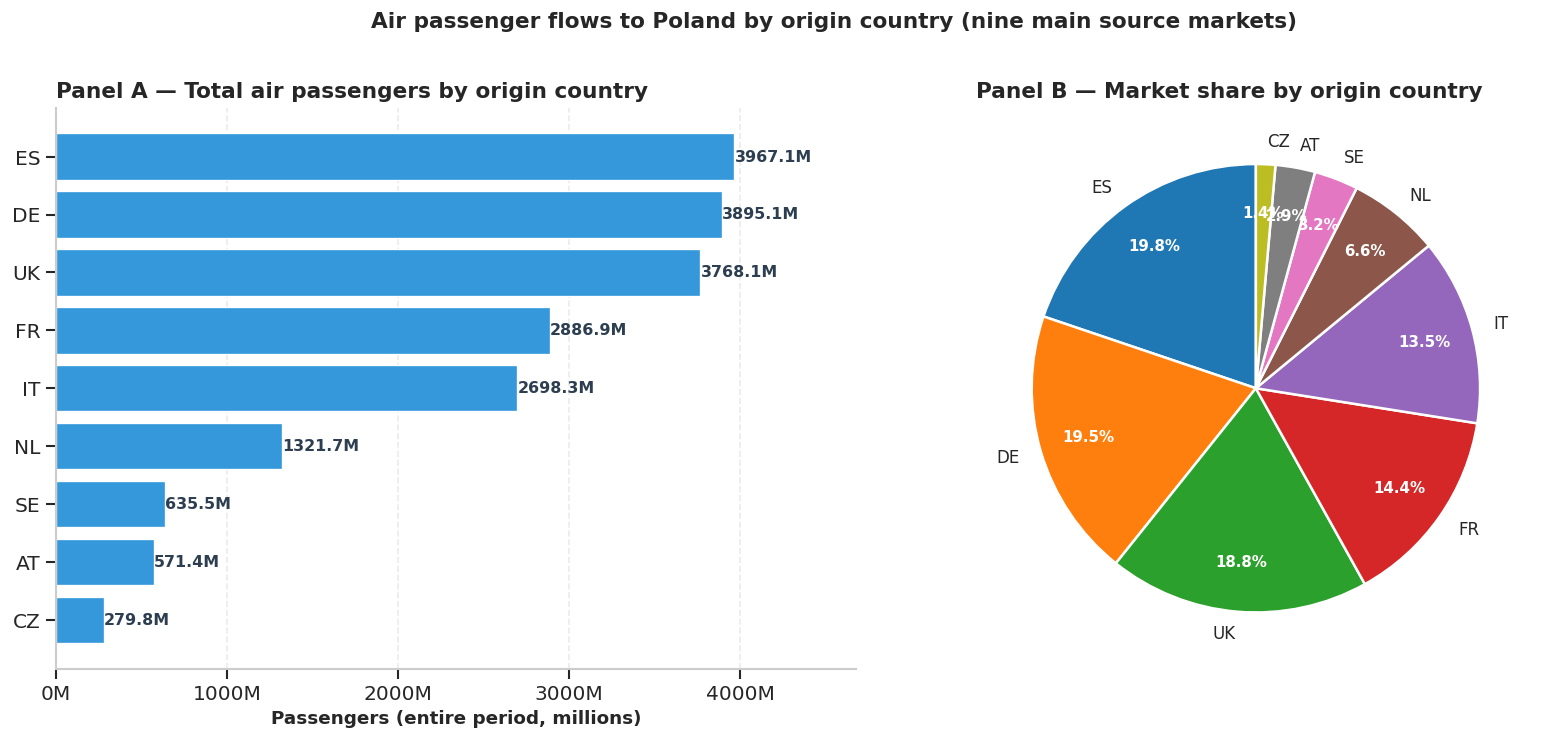


Market shares (verified):
  ES: 19.8%
  DE: 19.5%
  UK: 18.8%
  FR: 14.4%
  IT: 13.5%
  NL: 6.6%
  SE: 3.2%
  AT: 2.9%
  CZ: 1.4%


In [15]:
# --- BUILD THE TWO-PANEL FIGURE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# === PANEL A — Total passengers by origin (horizontal bar) ===
ax_a = axes[0]
bars = ax_a.barh(pax_total.index, pax_total.values / 1e6,
                  color=COLORS['accent1'], edgecolor='white', linewidth=0.8)

# Value labels
for bar, val in zip(bars, pax_total.values):
    ax_a.text(val/1e6 + 1, bar.get_y() + bar.get_height()/2,
               f'{val/1e6:.1f}M',
               va='center', fontsize=9.5, fontweight='bold',
               color=COLORS['primary'])

ax_a.set_xlabel('Passengers (entire period, millions)', fontweight='bold')
ax_a.set_title('Panel A — Total air passengers by origin country',
                fontweight='bold', loc='left')
ax_a.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:.0f}M'))
ax_a.set_xlim(0, pax_total.max()/1e6 * 1.18)
ax_a.grid(axis='y', alpha=0)
ax_a.grid(axis='x', alpha=0.4)

# === PANEL B — Market share pie chart ===
ax_b = axes[1]
shares = pax_total / pax_total.sum() * 100
shares_sorted = shares.sort_values(ascending=False)

# Build a colour list (highlight UK and DE as the largest)
pie_palette = sns.color_palette('tab10', n_colors=len(shares_sorted))

wedges, texts, autotexts = ax_b.pie(
    shares_sorted.values,
    labels=shares_sorted.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=pie_palette,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=10),
    pctdistance=0.78,
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

ax_b.set_title('Panel B — Market share by origin country',
                fontweight='bold', loc='left')

plt.suptitle('Air passenger flows to Poland by origin country '
              '(nine main source markets)',
              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig_2_1_origin_country_traffic.png')
plt.show()

# Print verified shares for the thesis text
print('\nMarket shares (verified):')
for iso, share in shares.sort_values(ascending=False).items():
    print(f'  {iso}: {share:.1f}%')

---



## Figure 2.2 — Foreign Overnight Stays in Poland: Monthly Series 2011–2025

Single headline chart of the target variable, with the 12-month moving average overlaid as a trend reference and key historical milestones annotated: pre-pandemic peak, pandemic trough, post-pandemic peak, and the moment when the smoothed trend recovers its pre-pandemic level. The strong annual seasonality of the raw monthly series is clearly visible.

**Source:** Eurostat `tour_occ_nights` (foreign visitors, all accommodation types).

In [9]:
# Add the nights file to the catalogue
FILES['nights'] = os.path.join(DATA_RAW, 'tourism',
                               'tour_occ_nights_accommodation_PL_2003-.csv')

# Load and filter (filter values match those verified in NB00)
df_nights_raw = load_eurostat(FILES['nights'])

ACCOM_TOTAL = ('Hotels; holiday and other short-stay accommodation; '
               'camping grounds, recreational vehicle parks and trailer parks')

mask = (
    (df_nights_raw['geo'] == 'Poland') &
    (df_nights_raw['c_resid'] == 'Foreign country') &
    (df_nights_raw['unit'] == 'Number') &
    (df_nights_raw['nace_r2'] == ACCOM_TOTAL)
)

df_target = df_nights_raw.loc[mask].copy()

# Clean time series indexed by date, restricted to the study period
ts_foreign = (df_target
              .set_index('date')['OBS_VALUE']
              .sort_index()
              .rename('nights'))
ts_foreign = ts_foreign[ts_foreign.index >= '2011-01-01']

print(f'Target series: {len(ts_foreign)} monthly observations')
print(f'Period: {ts_foreign.index.min():%Y-%m} -> {ts_foreign.index.max():%Y-%m}')
print(f'Range:  {ts_foreign.min():,.0f} - {ts_foreign.max():,.0f}')

Target series: 179 monthly observations
Period: 2011-01 -> 2025-11
Range:  83,695 - 2,453,961


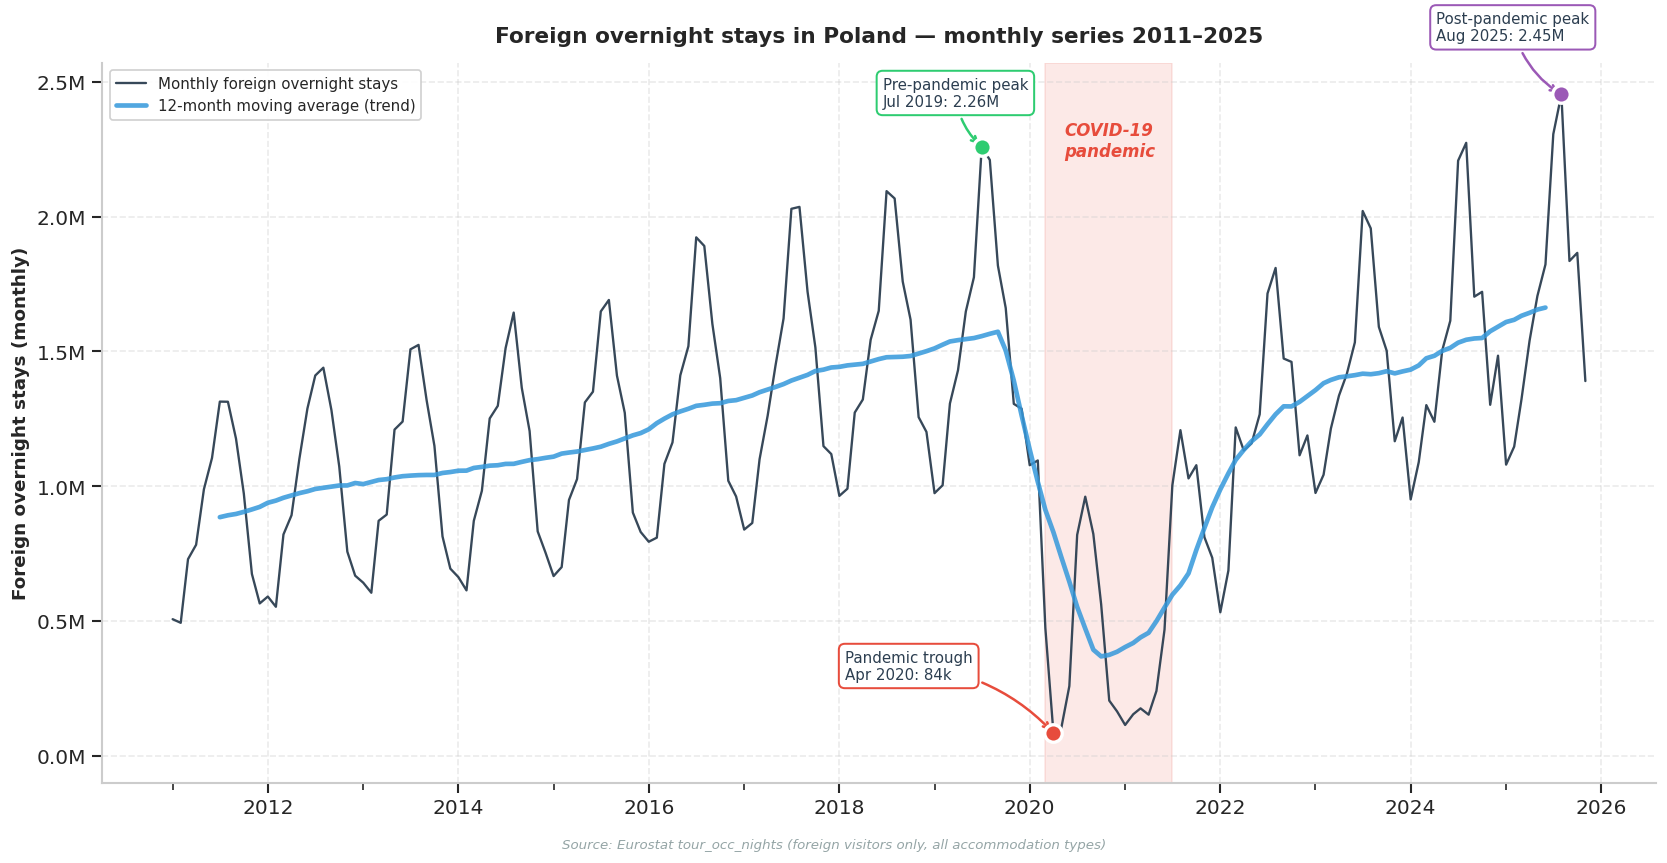


Key figures:
  Pre-pandemic peak:     2,260,446 (Jul 2019)
  Pandemic trough:          83,695 (Apr 2020)
  Post-pandemic peak:    2,453,961 (Aug 2025)
  Trough as % of pre-peak: 3.7%
  Post-peak vs pre-peak:   +8.6%


In [10]:
fig, ax = plt.subplots(figsize=(14, 7))

# --- Main line: raw monthly series ---
ax.plot(ts_foreign.index, ts_foreign.values,
        color=COLORS['primary'], linewidth=1.4, alpha=0.95,
        label='Monthly foreign overnight stays')

# --- Trend: 12-month centred moving average ---
trend = ts_foreign.rolling(12, center=True).mean()
ax.plot(trend.index, trend.values,
        color=COLORS['accent1'], linewidth=2.8, alpha=0.85,
        label='12-month moving average (trend)')

# --- COVID-19 shaded band with label ---
ax.axvspan(COVID_START, COVID_END,
           color=COLORS['covid'], alpha=0.12, zorder=0)
ax.text(pd.Timestamp('2020-11-01'),
        ts_foreign.max() * 0.96,
        'COVID-19\npandemic',
        ha='center', va='top', fontsize=10, fontweight='bold',
        color=COLORS['secondary'], style='italic')

# --- Milestone 1: pre-pandemic peak ---
pre_covid = ts_foreign[ts_foreign.index < '2020-01-01']
pre_peak_date = pre_covid.idxmax()
pre_peak_val  = pre_covid.max()
ax.scatter([pre_peak_date], [pre_peak_val],
           s=110, color=COLORS['accent2'], zorder=5,
           edgecolor='white', linewidth=2)
ax.annotate(f'Pre-pandemic peak\n{pre_peak_date:%b %Y}: '
            f'{pre_peak_val/1e6:.2f}M',
            xy=(pre_peak_date, pre_peak_val),
            xytext=(pre_peak_date - pd.Timedelta(days=380),
                    pre_peak_val + 150000),
            fontsize=9, color=COLORS['primary'],
            arrowprops=dict(arrowstyle='->', color=COLORS['accent2'],
                            lw=1.5, connectionstyle='arc3,rad=0.2'),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=COLORS['accent2'], lw=1.2))

# --- Milestone 2: pandemic trough ---
covid_period = ts_foreign[(ts_foreign.index >= '2020-03-01') &
                          (ts_foreign.index <= '2021-06-01')]
trough_date = covid_period.idxmin()
trough_val  = covid_period.min()
ax.scatter([trough_date], [trough_val],
           s=110, color=COLORS['secondary'], zorder=5,
           edgecolor='white', linewidth=2)
ax.annotate(f'Pandemic trough\n{trough_date:%b %Y}: '
            f'{trough_val/1e3:.0f}k',
            xy=(trough_date, trough_val),
            xytext=(trough_date - pd.Timedelta(days=800),
                    trough_val + 200000),
            fontsize=9, color=COLORS['primary'],
            arrowprops=dict(arrowstyle='->', color=COLORS['secondary'],
                            lw=1.5, connectionstyle='arc3,rad=-0.2'),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=COLORS['secondary'], lw=1.2))

# --- Milestone 3: post-pandemic peak ---
post_covid_data = ts_foreign[ts_foreign.index >= '2023-01-01']
post_peak_date = post_covid_data.idxmax()
post_peak_val  = post_covid_data.max()
ax.scatter([post_peak_date], [post_peak_val],
           s=110, color=COLORS['accent4'], zorder=5,
           edgecolor='white', linewidth=2)
ax.annotate(f'Post-pandemic peak\n{post_peak_date:%b %Y}: '
            f'{post_peak_val/1e6:.2f}M',
            xy=(post_peak_date, post_peak_val),
            xytext=(post_peak_date - pd.Timedelta(days=480),
                    post_peak_val + 200000),
            fontsize=9, color=COLORS['primary'],
            arrowprops=dict(arrowstyle='->', color=COLORS['accent4'],
                            lw=1.5, connectionstyle='arc3,rad=0.2'),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=COLORS['accent4'], lw=1.2))

# --- Milestone 4: trend recovery date ---
trend_no_nan = trend.dropna()
above_peak = trend_no_nan[(trend_no_nan.index >= '2022-01-01') &
                          (trend_no_nan > pre_peak_val * 0.95)]
if len(above_peak) > 0:
    recovery_date = above_peak.index[0]
    ax.axvline(recovery_date, color=COLORS['accent2'], linestyle=':',
               linewidth=1.5, alpha=0.6)
    ylim = ax.get_ylim()
    ax.text(recovery_date, ylim[0] + (ylim[1] - ylim[0]) * 0.04,
            f'  Trend recovers\n  pre-pandemic level\n  ({recovery_date:%b %Y})',
            fontsize=8.5, color=COLORS['accent2'], style='italic',
            va='bottom', ha='left')

# --- Axes formatting ---
ax.set_ylabel('Foreign overnight stays (monthly)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.set_ylim(bottom=-100000)

ax.legend(loc='upper left', frameon=True, framealpha=0.92)

plt.title('Foreign overnight stays in Poland — monthly series 2011–2025',
          fontweight='bold', pad=12)

fig.text(0.5, -0.015,
         'Source: Eurostat tour_occ_nights '
         '(foreign visitors only, all accommodation types)',
         ha='center', fontsize=8, style='italic', color=COLORS['gray'])

plt.tight_layout()
savefig('fig_2_2_nights_overview.png')
plt.show()

# --- Print key statistics for the thesis text ---
print(f'\nKey figures:')
print(f'  Pre-pandemic peak:  {pre_peak_val:>12,.0f} ({pre_peak_date:%b %Y})')
print(f'  Pandemic trough:    {trough_val:>12,.0f} ({trough_date:%b %Y})')
print(f'  Post-pandemic peak: {post_peak_val:>12,.0f} ({post_peak_date:%b %Y})')
print(f'  Trough as % of pre-peak: {trough_val/pre_peak_val*100:.1f}%')
print(f'  Post-peak vs pre-peak:   '
      f'{(post_peak_val/pre_peak_val - 1)*100:+.1f}%')
if len(above_peak) > 0:
    months_to_recover = (recovery_date.to_period('M') -
                         pre_peak_date.to_period('M')).n
    print(f'  Months to trend recovery: {months_to_recover}')

---

## Figure 4.3 — UK Chain-Linking: Eurostat + ONS

Two-panel figure documenting the statistical chain-linking applied to the UK series. Panel A shows the monthly HICP series with the Eurostat segment, the ONS-derived rescaled segment, and the splice point marked. Panel B shows the analogous treatment for quarterly real GDP. The continuity of the composite series across the splice point is the visual evidence that the chain-linking factor was correctly estimated.

**Sources:** Eurostat `prc_hicp_midx` and `namq_10_gdp`; ONS series D7BT (HICP CPIH) and ABMI (GDP at constant prices).

In [48]:
# Add ONS files to the catalogue if not already present
FILES['hicp_uk'] = os.path.join(DATA_RAW, 'uk_specific', 'ons_hicp_uk_d7bt.csv')
FILES['gdp_uk']  = os.path.join(DATA_RAW, 'uk_specific', 'ons_gdp_uk_abmi.csv')

# --- LOAD AND REBUILD UK HICP CHAIN-LINK FROM SCRATCH ---
# We need the SEPARATE Eurostat and ONS series for the plot, not the
# already-spliced composite. So we re-run the chain-link logic of NB00,
# but keeping both the original Eurostat segment and the ONS rescaled
# segment as separate objects.

# Eurostat HICP UK (monthly, base 2015=100)
df_hicp = load_eurostat(FILES['hicp_midx'])
hicp_uk_eu = (df_hicp[df_hicp['geo'] == 'United Kingdom']
              .set_index('date')['OBS_VALUE']
              .sort_index().dropna())
print(f'Eurostat UK HICP: {len(hicp_uk_eu)} months  '
      f'({hicp_uk_eu.index.min():%Y-%m} -> {hicp_uk_eu.index.max():%Y-%m})')

# ONS HICP UK (D7BT, monthly)
ons_hicp = load_ons(FILES['hicp_uk'], frequency='monthly')
print(f'ONS HICP UK:      {len(ons_hicp)} months  '
      f'({ons_hicp.index.min():%Y-%m} -> {ons_hicp.index.max():%Y-%m})')

# Compute chain-link factor at the last Eurostat observation
last_overlap_h = hicp_uk_eu.index[-1]
if last_overlap_h in ons_hicp.index:
    factor_h = hicp_uk_eu.iloc[-1] / ons_hicp.loc[last_overlap_h]
else:
    closest_h = ons_hicp.index[ons_hicp.index <= last_overlap_h][-1]
    factor_h = hicp_uk_eu.iloc[-1] / ons_hicp.loc[closest_h]
    last_overlap_h = closest_h

ons_hicp_rescaled = ons_hicp * factor_h
print(f'Chain-link factor (HICP) at {last_overlap_h:%Y-%m}: {factor_h:.4f}')

# --- LOAD AND REBUILD UK GDP CHAIN-LINK FROM SCRATCH ---
df_gdp = load_eurostat(FILES['gdp_real'])
gdp_uk_eu = (df_gdp[df_gdp['geo'] == 'United Kingdom']
             .set_index('date')['OBS_VALUE']
             .sort_index().dropna())
print(f'\nEurostat UK GDP: {len(gdp_uk_eu)} quarters '
      f'({gdp_uk_eu.index.min():%Y-%m} -> {gdp_uk_eu.index.max():%Y-%m})')

ons_gdp = load_ons(FILES['gdp_uk'], frequency='quarterly')
print(f'ONS GDP UK:      {len(ons_gdp)} quarters '
      f'({ons_gdp.index.min():%Y-%m} -> {ons_gdp.index.max():%Y-%m})')

last_overlap_g = gdp_uk_eu.index[-1]
if last_overlap_g in ons_gdp.index:
    factor_g = gdp_uk_eu.iloc[-1] / ons_gdp.loc[last_overlap_g]
else:
    closest_g = ons_gdp.index[ons_gdp.index <= last_overlap_g][-1]
    factor_g = gdp_uk_eu.iloc[-1] / ons_gdp.loc[closest_g]
    last_overlap_g = closest_g

ons_gdp_rescaled = ons_gdp * factor_g
print(f'Chain-link factor (GDP) at {last_overlap_g:%Y-%m}: {factor_g:.4f}')
print(f'  (absorbs GBP -> EUR conversion and base year difference)')

Eurostat UK HICP: 215 months  (2003-01 -> 2020-11)
ONS HICP UK:      458 months  (1988-01 -> 2026-02)
Chain-link factor (HICP) at 2020-11: 1.0000

Eurostat UK GDP: 103 quarters (1995-01 -> 2020-07)
ONS GDP UK:      284 quarters (1955-01 -> 2025-10)
Chain-link factor (GDP) at 2020-07: 0.8251
  (absorbs GBP -> EUR conversion and base year difference)


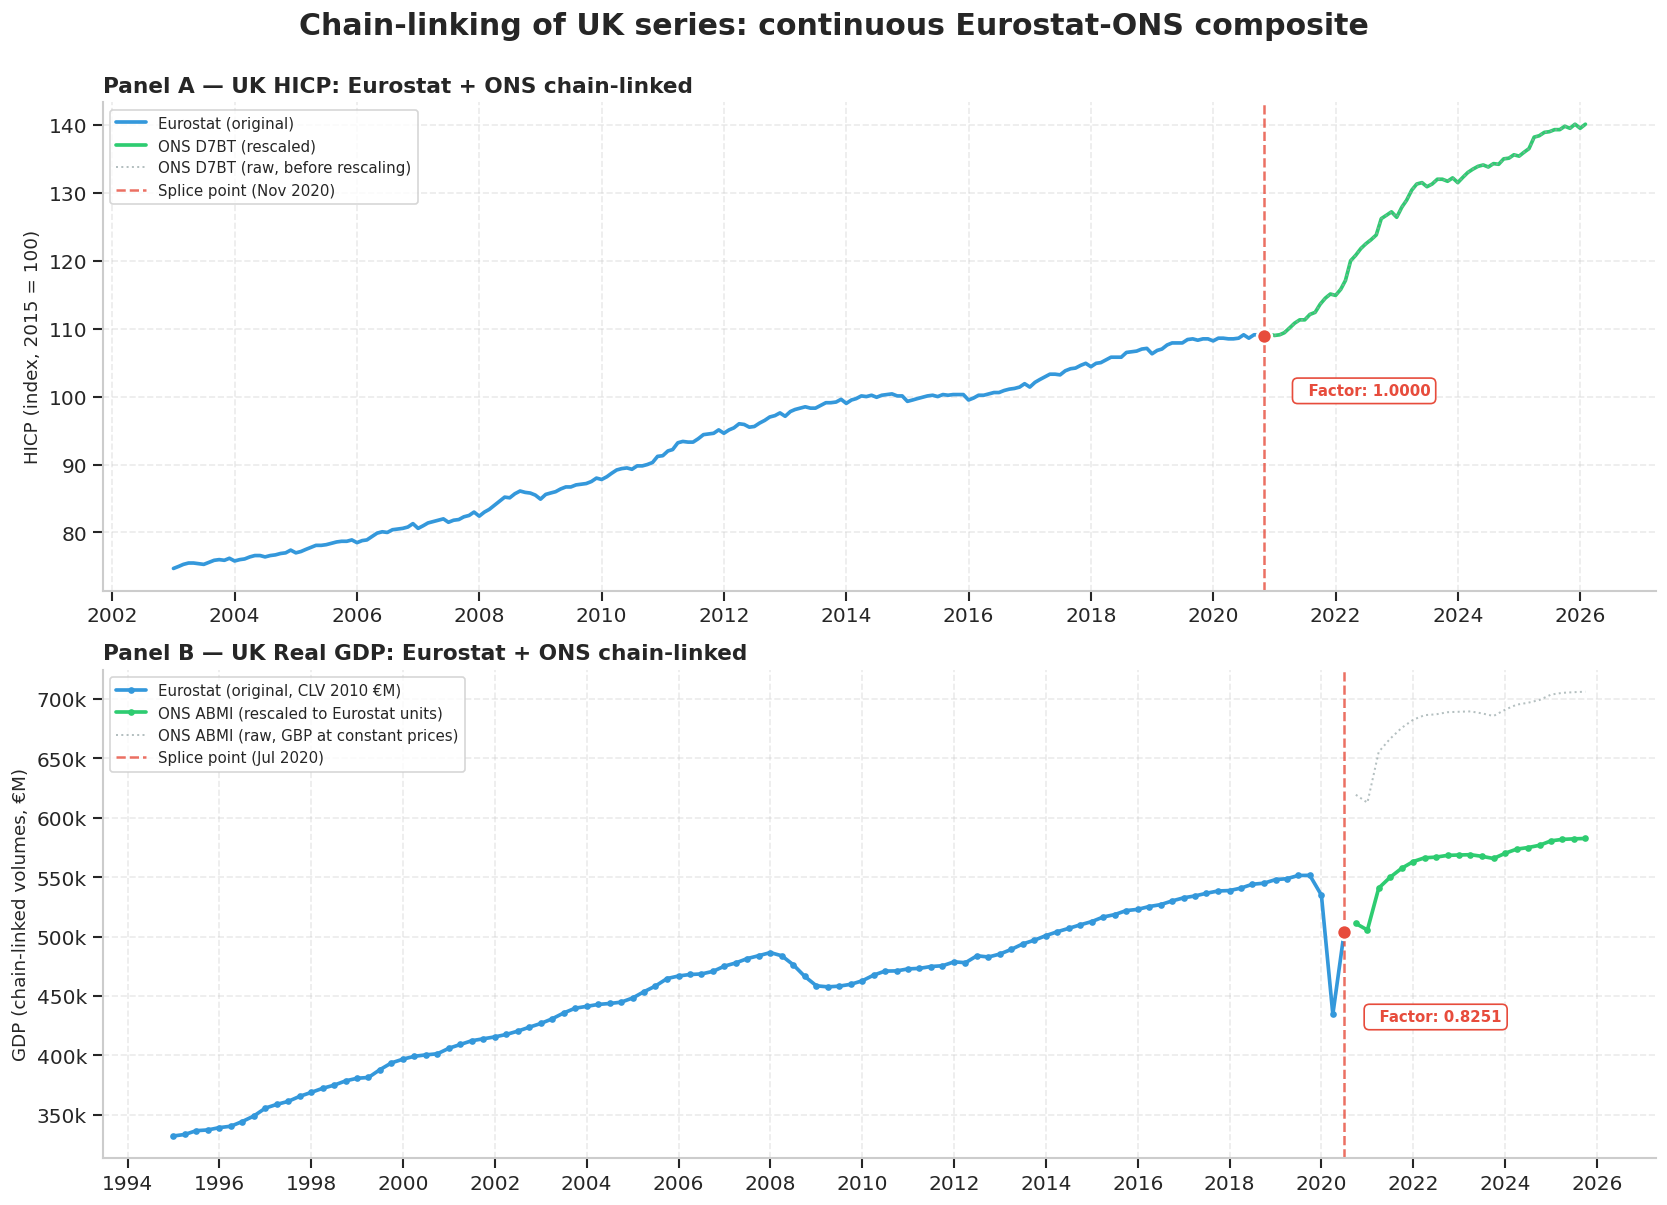

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [1, 1]})

# === PANEL A: HICP ===
ax = axes[0]
ax.plot(hicp_uk_eu.index, hicp_uk_eu.values,
        color=COLORS['accent1'], lw=2.2, label='Eurostat (original)')

ons_h_after = ons_hicp_rescaled.loc[ons_hicp_rescaled.index > last_overlap_h]
ax.plot(ons_h_after.index, ons_h_after.values,
        color=COLORS['accent2'], lw=2.2, label='ONS D7BT (rescaled)')

# Show the raw (unrescaled) ONS as context, so the chain-link adjustment is visible
ons_h_raw_after = ons_hicp.loc[ons_hicp.index > last_overlap_h]
ax.plot(ons_h_raw_after.index, ons_h_raw_after.values,
        color=COLORS['gray'], lw=1.2, ls=':', alpha=0.7,
        label='ONS D7BT (raw, before rescaling)')

ax.axvline(last_overlap_h, color=COLORS['secondary'],
           ls='--', lw=1.5, alpha=0.8,
           label=f'Splice point ({last_overlap_h:%b %Y})')

splice_val_h = hicp_uk_eu.loc[last_overlap_h]
ax.scatter([last_overlap_h], [splice_val_h], s=80,
           color=COLORS['secondary'], zorder=5,
           edgecolor='white', linewidth=1.5)
ax.annotate(f'  Factor: {factor_h:.4f}',
            xy=(last_overlap_h, splice_val_h),
            xytext=(last_overlap_h + pd.Timedelta(days=200),
                    splice_val_h * 0.92),
            fontsize=9, fontweight='bold', color=COLORS['secondary'],
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor=COLORS['secondary'], lw=1))

ax.set_title('Panel A — UK HICP: Eurostat + ONS chain-linked',
              fontweight='bold', loc='left')
ax.set_ylabel('HICP (index, 2015 = 100)')
ax.legend(loc='upper left', frameon=True, fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# === PANEL B: GDP ===
ax = axes[1]
ax.plot(gdp_uk_eu.index, gdp_uk_eu.values,
        color=COLORS['accent1'], lw=2.2, marker='o', ms=3,
        label='Eurostat (original, CLV 2010 €M)')

ons_g_after = ons_gdp_rescaled.loc[ons_gdp_rescaled.index > last_overlap_g]
ax.plot(ons_g_after.index, ons_g_after.values,
        color=COLORS['accent2'], lw=2.2, marker='o', ms=3,
        label='ONS ABMI (rescaled to Eurostat units)')

ons_g_raw_after = ons_gdp.loc[ons_gdp.index > last_overlap_g]
ax.plot(ons_g_raw_after.index, ons_g_raw_after.values,
        color=COLORS['gray'], lw=1.2, ls=':', alpha=0.7,
        label='ONS ABMI (raw, GBP at constant prices)')

ax.axvline(last_overlap_g, color=COLORS['secondary'],
           ls='--', lw=1.5, alpha=0.8,
           label=f'Splice point ({last_overlap_g:%b %Y})')

splice_val_g = gdp_uk_eu.loc[last_overlap_g]
ax.scatter([last_overlap_g], [splice_val_g], s=80,
           color=COLORS['secondary'], zorder=5,
           edgecolor='white', linewidth=1.5)
ax.annotate(f'  Factor: {factor_g:.4f}',
            xy=(last_overlap_g, splice_val_g),
            xytext=(last_overlap_g + pd.Timedelta(days=200),
                    splice_val_g * 0.85),
            fontsize=9, fontweight='bold', color=COLORS['secondary'],
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor=COLORS['secondary'], lw=1))

ax.set_title('Panel B — UK Real GDP: Eurostat + ONS chain-linked',
              fontweight='bold', loc='left')
ax.set_ylabel('GDP (chain-linked volumes, €M)')
ax.legend(loc='upper left', frameon=True, fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1000:.0f}k'))

plt.suptitle('Chain-linking of UK series: continuous Eurostat-ONS composite',
              fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
savefig('fig_4_3_chain_linking_uk.png')
plt.show()

---

## Figure 4.4 — Target Variable Characterisation

Three-panel figure that summarises the target series. Panel A shows the raw monthly series 2011–2025 with the COVID-19 period shaded; Panel B shows the year-over-year growth rate as a bar chart with positive bars in green and negative in red; Panel C shows a year × month heatmap that exposes the strong seasonal concentration in summer and the "dark patch" of 2020–2021 corresponding to the pandemic collapse.

**Source:** Eurostat `tour_occ_nights` (foreign visitors only, all accommodation types).

In [11]:
# Reuse ts_foreign already computed in Figure 2.2 section
# (if you generate this notebook out of order, uncomment the following lines)
# FILES['nights'] = os.path.join(DATA_RAW, 'tourism',
#                                'tour_occ_nights_accommodation_PL_2003-.csv')
# df_nights_raw = load_eurostat(FILES['nights'])
# ACCOM_TOTAL = ('Hotels; holiday and other short-stay accommodation; '
#                'camping grounds, recreational vehicle parks and trailer parks')
# mask = ((df_nights_raw['geo'] == 'Poland') &
#         (df_nights_raw['c_resid'] == 'Foreign country') &
#         (df_nights_raw['unit'] == 'Number') &
#         (df_nights_raw['nace_r2'] == ACCOM_TOTAL))
# ts_foreign = (df_nights_raw.loc[mask].set_index('date')['OBS_VALUE']
#               .sort_index().rename('nights'))
# ts_foreign = ts_foreign[ts_foreign.index >= '2011-01-01']

# --- COMPUTE DERIVED SERIES ---
yoy = ts_foreign.pct_change(12) * 100

# Year x month matrix for the heatmap
heatmap_df = ts_foreign.to_frame('nights').copy()
heatmap_df['year']  = heatmap_df.index.year
heatmap_df['month'] = heatmap_df.index.month
heatmap_matrix = heatmap_df.pivot(
    index='year', columns='month', values='nights') / 1e6   # in millions

print(f'Heatmap matrix shape: {heatmap_matrix.shape}')
print(f'Year range:  {heatmap_matrix.index.min()}-{heatmap_matrix.index.max()}')
print(f'Range:       {heatmap_matrix.min().min():.2f}M – '
      f'{heatmap_matrix.max().max():.2f}M nights/month')

Heatmap matrix shape: (15, 12)
Year range:  2011-2025
Range:       0.08M – 2.45M nights/month


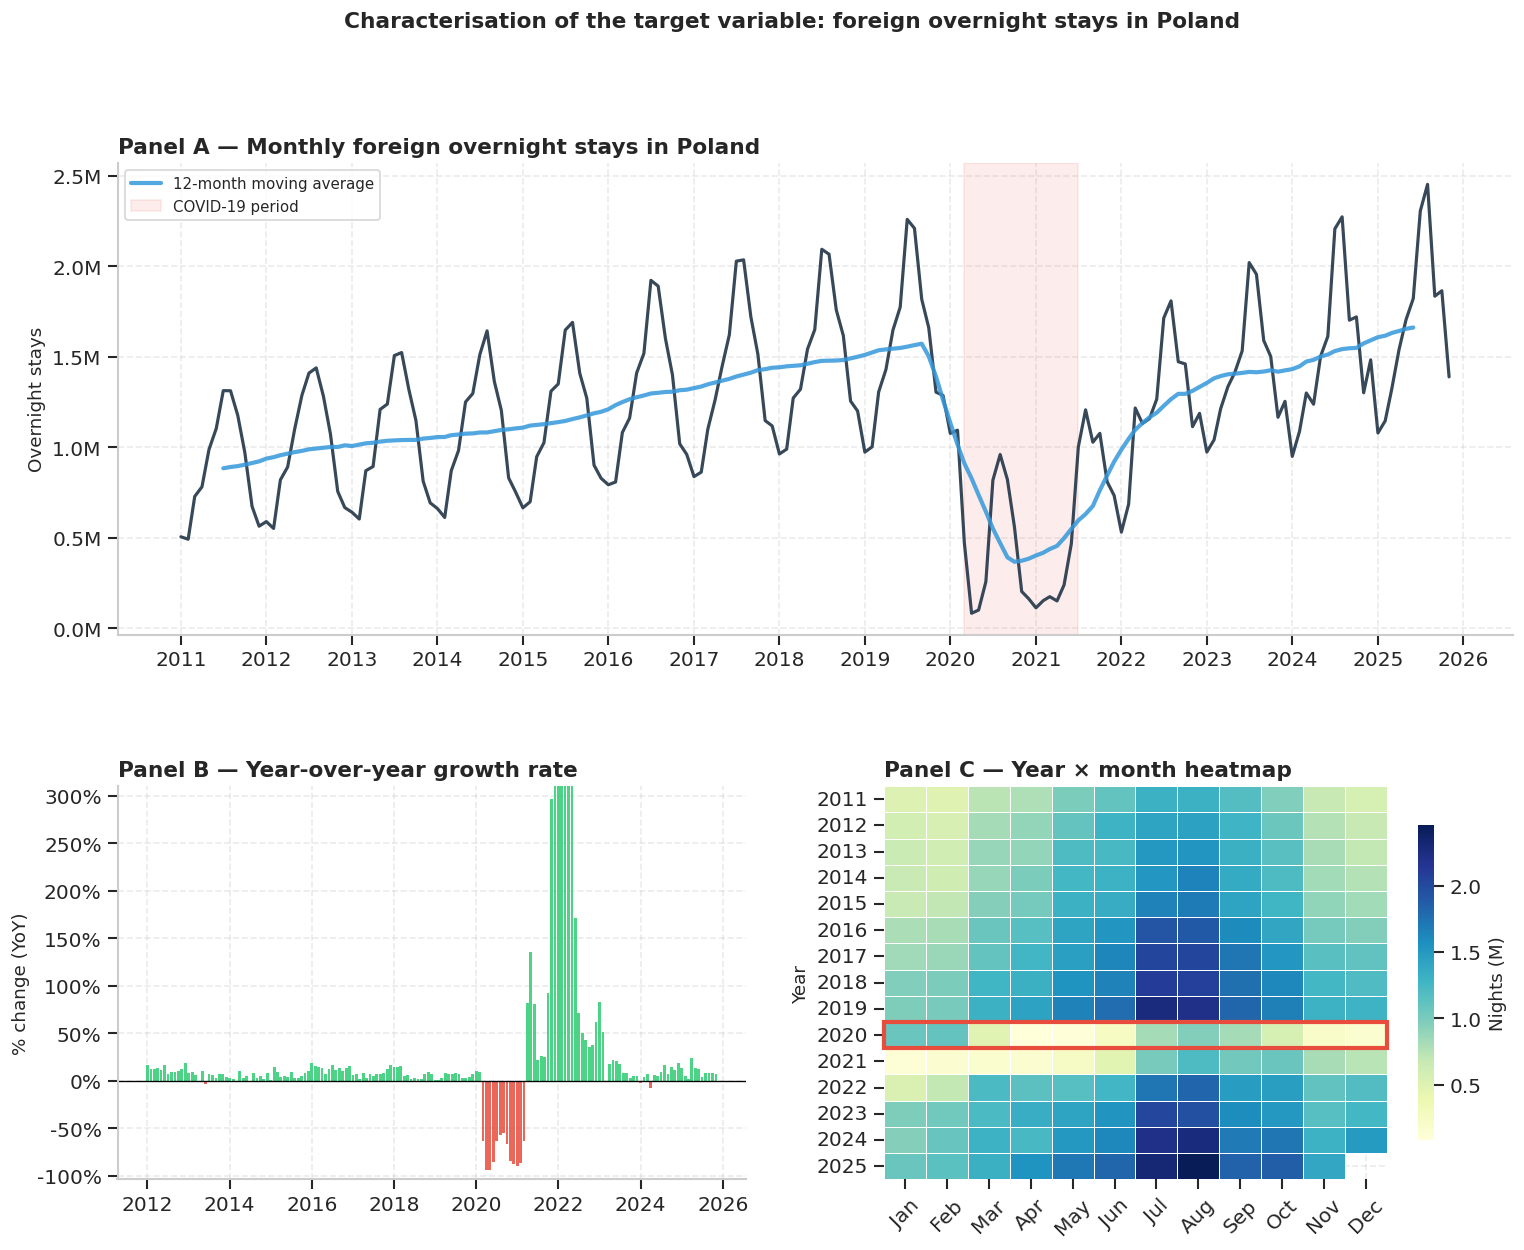


Pre-COVID peak:       2,260,446  (Jul 2019)
COVID trough:            83,695  (Apr 2020)
Latest value:         1,390,200  (Nov 2025)
Max YoY decline:   -94.1%  (Apr 2020)
Avg peak/trough ratio (Aug/Jan): 2.33


In [17]:
# --- BUILD THE THREE-PANEL FIGURE ---
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 11))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1.0], hspace=0.35, wspace=0.22)

# === PANEL A: RAW MONTHLY SERIES (full width) ===
ax_a = fig.add_subplot(gs[0, :])
ax_a.plot(ts_foreign.index, ts_foreign.values,
          color=COLORS['primary'], linewidth=1.9, alpha=0.95)
# 12-month rolling mean overlaid
trend = ts_foreign.rolling(12, center=True).mean()
ax_a.plot(trend.index, trend.values,
          color=COLORS['accent1'], linewidth=2.5, alpha=0.85,
          label='12-month moving average')
covid_shade(ax_a)
ax_a.set_title('Panel A — Monthly foreign overnight stays in Poland',
                fontweight='bold', loc='left')
ax_a.set_ylabel('Overnight stays')
ax_a.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))
ax_a.legend(loc='upper left', frameon=True, fontsize=9)
ax_a.xaxis.set_major_locator(mdates.YearLocator(1))
ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_a.tick_params(axis='x', rotation=0)

# === PANEL B: YoY GROWTH (bottom-left) ===
ax_b = fig.add_subplot(gs[1, 0])
bar_colors = [COLORS['accent2'] if v >= 0 else COLORS['secondary']
              for v in yoy.values]
ax_b.bar(yoy.index, yoy.values, color=bar_colors, width=25, alpha=0.85)
ax_b.axhline(0, color='black', linewidth=0.8)
ax_b.set_title('Panel B — Year-over-year growth rate',
                fontweight='bold', loc='left')
ax_b.set_ylabel('% change (YoY)')
ax_b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax_b.set_ylim(max(-110, np.nanmin(yoy) * 1.1),
               min(310, np.nanmax(yoy) * 1.1))
ax_b.xaxis.set_major_locator(mdates.YearLocator(2))
ax_b.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# === PANEL C: YEAR x MONTH HEATMAP (bottom-right) ===
ax_c = fig.add_subplot(gs[1, 1])
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
hm = sns.heatmap(heatmap_matrix, ax=ax_c, cmap='YlGnBu',
                  cbar_kws={'label': 'Nights (M)', 'shrink': 0.8},
                  linewidths=0.4, linecolor='white',
                  xticklabels=month_labels, yticklabels=True,
                  annot=False)
ax_c.set_title('Panel C — Year × month heatmap',
                fontweight='bold', loc='left')
ax_c.set_xlabel('')
ax_c.set_ylabel('Year')
ax_c.tick_params(axis='x', rotation=45)
ax_c.tick_params(axis='y', rotation=0)
# Add a thin red border around the COVID year (2020) for emphasis
if 2020 in heatmap_matrix.index:
    covid_y = heatmap_matrix.index.get_loc(2020)
    from matplotlib.patches import Rectangle
    ax_c.add_patch(Rectangle((0, covid_y), 12, 1,
                             fill=False, edgecolor=COLORS['secondary'],
                             lw=2.5, clip_on=False))

plt.suptitle('Characterisation of the target variable: foreign overnight stays in Poland',
              fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
savefig('fig_4_4_target_characterization.png')
plt.show()

# --- KEY STATISTICS FOR THE THESIS TEXT ---
pre_covid = ts_foreign[ts_foreign.index < '2020-01-01']
covid_period = ts_foreign[(ts_foreign.index >= '2020-03-01') &
                          (ts_foreign.index <= '2021-06-01')]
print(f'\nPre-COVID peak:    {pre_covid.max():>12,.0f}  ({pre_covid.idxmax():%b %Y})')
print(f'COVID trough:      {covid_period.min():>12,.0f}  ({covid_period.idxmin():%b %Y})')
print(f'Latest value:      {ts_foreign.iloc[-1]:>12,.0f}  ({ts_foreign.index[-1]:%b %Y})')
print(f'Max YoY decline:   {yoy.min():.1f}%  ({yoy.idxmin():%b %Y})')
print(f'Avg peak/trough ratio (Aug/Jan): '
      f'{heatmap_matrix[8].mean()/heatmap_matrix[1].mean():.2f}')

---

## Figure 4.5 — Cross-Correlation Heatmaps: Levels vs Year-over-Year

Two-panel cross-correlation analysis between the target series (foreign overnight stays) and each candidate predictor at lags 0 to 12 months. Panel A uses both series in levels — the absolute values — and is contaminated by shared secular trends that produce spuriously high correlations. Panel B uses both series in year-over-year growth terms, which removes the trend component and reveals the true relational structure at each lag. The lag corresponding to the maximum absolute correlation in Panel B is used as the empirical justification for the chosen lag of each predictor in NB04.

**Source:** computed from the consolidated panel of NB02.

In [18]:
# This figure assumes the consolidated panel from NB02 is already saved
# on disk. If you run the figure notebook standalone, load it here:
panel = pd.read_csv(
    os.path.join('..', '..', 'data', 'processed', 'master_panel_monthly.csv'),
    index_col=0, parse_dates=True
)
panel.index.name = 'date'

# Verify the columns we will use
print(f'Panel shape: {panel.shape}')
print(f'Period: {panel.index.min():%Y-%m} -> {panel.index.max():%Y-%m}')

predictor_cols = [
    'hicp_ratio', 'exr_pln', 'relprice_wavg',
    'gdp_origins_wavg', 'gdp_DE',
    'cci_origins_wavg', 'cci_DE', 'seats',
]
predictor_cols = [c for c in predictor_cols if c in panel.columns]
print(f'Available predictors: {predictor_cols}')

Panel shape: (179, 39)
Period: 2011-01 -> 2025-11
Available predictors: ['hicp_ratio', 'exr_pln', 'relprice_wavg', 'gdp_origins_wavg', 'gdp_DE', 'cci_DE', 'seats']


In [22]:
from scipy import stats

def cross_correlation_lags(target, predictor, max_lag=12):
    """Pearson correlation between target(t) and predictor(t-k) for k=0..max_lag.
    
    Robust to NaN and infinite values, which can arise from pct_change on
    series with values near zero (e.g., consumer confidence indicators).
    """
    results = {}
    for lag in range(max_lag + 1):
        pred_lagged = predictor.shift(lag)
        valid = pd.concat([target, pred_lagged], axis=1)
        # Replace any infinities with NaN, then drop all rows with NaN or inf
        valid = valid.replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) > 20:
            r, _ = stats.pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
            results[lag] = r
        else:
            results[lag] = np.nan
    return pd.Series(results)


def yoy_transform(series, kind='auto'):
    """Apply the appropriate year-over-year transform.
    
    For strictly positive series (HICP, GDP, seats, prices), use percentage
    change. For series that can take negative or near-zero values (CCI),
    use absolute year-over-year difference instead, which has the same
    interpretive purpose (removing the trend / level) without numerical
    instability.
    """
    if kind == 'pct':
        return series.pct_change(12)
    if kind == 'diff':
        return series.diff(12)
    # Auto: if any value is <= 0 (or very close), use diff; else use pct_change
    if (series <= 1e-6).any():
        return series.diff(12)
    else:
        return series.pct_change(12)

In [23]:
# Variables that should be treated with pct_change (always positive, interpretable as rate)
PCT_CHANGE_VARS = {
    'hicp_ratio', 'exr_pln', 'relprice_wavg',
    'gdp_origins_wavg', 'gdp_DE',
    'seats',
}
# Variables that should be treated with diff (can be near zero or negative)
DIFF_VARS = {'cci_origins_wavg', 'cci_DE'}

# --- LEVELS-BASED CROSS-CORRELATIONS ---
target_levels = panel['nights'].dropna()
ccf_levels = {}
for col in predictor_cols:
    ccf_levels[col] = cross_correlation_lags(
        target_levels, panel[col].dropna(), max_lag=12)
ccf_df_levels = pd.DataFrame(ccf_levels)
ccf_df_levels.index.name = 'lag'

# --- YoY-BASED CROSS-CORRELATIONS ---
# Target: always pct_change because nights is always positive
target_yoy = panel['nights'].pct_change(12).dropna()
ccf_yoy = {}
for col in predictor_cols:
    if col in DIFF_VARS:
        predictor_yoy = panel[col].diff(12).dropna()
    else:
        predictor_yoy = panel[col].pct_change(12).dropna()
    # Filter any infs that survived
    predictor_yoy = predictor_yoy.replace([np.inf, -np.inf], np.nan).dropna()
    ccf_yoy[col] = cross_correlation_lags(target_yoy, predictor_yoy, max_lag=12)
ccf_df_yoy = pd.DataFrame(ccf_yoy)
ccf_df_yoy.index.name = 'lag'

print('--- Levels correlations (sample) ---')
print(ccf_df_levels.round(2).head(5))
print('\n--- YoY correlations (sample) ---')
print(ccf_df_yoy.round(2).head(5))
print(f'\nAny NaN in YoY correlations? {ccf_df_yoy.isna().any().any()}')

--- Levels correlations (sample) ---
     hicp_ratio  exr_pln  relprice_wavg  gdp_origins_wavg  gdp_DE  cci_DE  \
lag                                                                         
0          0.22    -0.09           0.33              0.48    0.37   -0.02   
1          0.24    -0.11           0.35              0.48    0.37    0.00   
2          0.25    -0.11           0.36              0.46    0.35    0.00   
3          0.26    -0.09           0.36              0.44    0.32   -0.01   
4          0.28    -0.06           0.35              0.41    0.30   -0.03   

     seats  
lag         
0     0.88  
1     0.83  
2     0.71  
3     0.55  
4     0.39  

--- YoY correlations (sample) ---
     hicp_ratio  exr_pln  relprice_wavg  gdp_origins_wavg  gdp_DE  cci_DE  \
lag                                                                         
0          0.19     0.06          -0.06              0.42    0.30   -0.07   
1          0.15     0.05          -0.08              0.48    0.36 

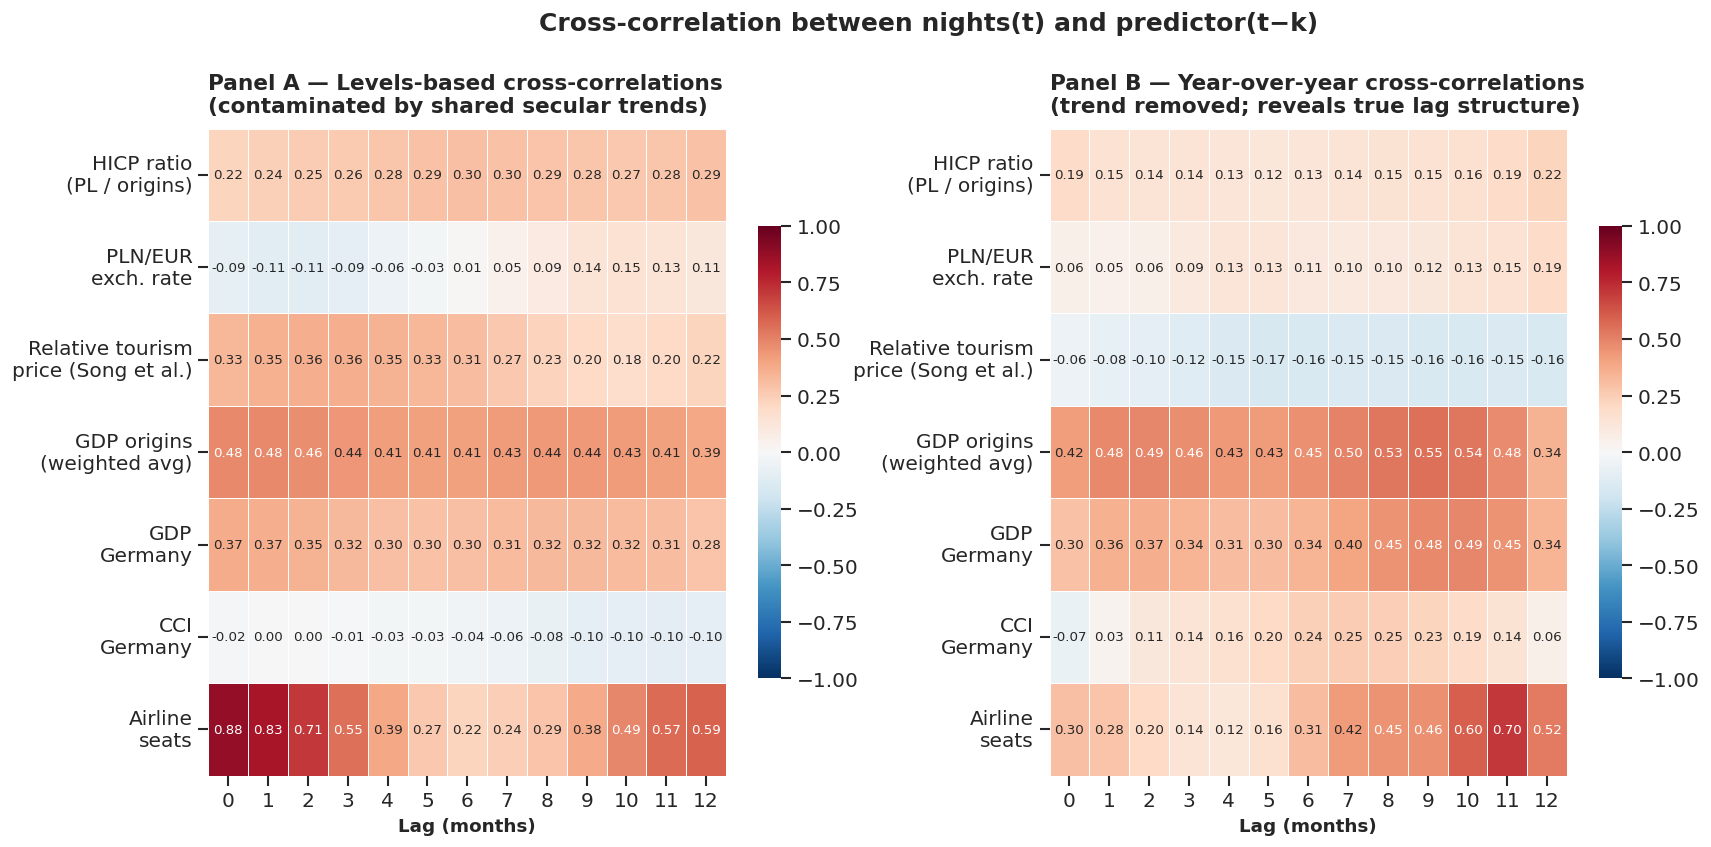


=== OPTIMAL LAG BY PREDICTOR (max |corr|) ===
Predictor                       Levels             YoY
--------------------------------------------------------
hicp_ratio              k= 6 (r=+0.30)  k=12 (r=+0.22)
exr_pln                 k=10 (r=+0.15)  k=12 (r=+0.19)
relprice_wavg           k= 3 (r=+0.36)  k= 5 (r=-0.17)
gdp_origins_wavg        k= 1 (r=+0.48)  k= 9 (r=+0.55)
gdp_DE                  k= 0 (r=+0.37)  k=10 (r=+0.49)
cci_DE                  k=11 (r=-0.10)  k= 7 (r=+0.25)
seats                   k= 0 (r=+0.88)  k=11 (r=+0.70)


In [41]:
display_names = {
    'hicp_ratio':       'HICP ratio\n(PL / origins)',
    'exr_pln':          'PLN/EUR\nexch. rate',
    'relprice_wavg':    'Relative tourism\nprice (Song et al.)',
    'gdp_origins_wavg': 'GDP origins\n(weighted avg)',
    'gdp_DE':           'GDP\nGermany',
    'cci_origins_wavg': 'CCI origins\n(weighted avg)',
    'cci_DE':           'CCI\nGermany',
    'seats':            'Airline\nseats',
}

ccf_levels_display = ccf_df_levels.rename(columns=display_names)
ccf_yoy_display    = ccf_df_yoy.rename(columns=display_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={'wspace': 0.3})

# === PANEL A: LEVELS ===
ax_a = axes[0]
sns.heatmap(ccf_levels_display.T, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax_a, linewidths=0.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.7})
ax_a.set_xlabel('Lag (months)', fontweight='bold')
ax_a.set_ylabel('')
ax_a.set_title('Panel A — Levels-based cross-correlations\n'
                '(contaminated by shared secular trends)',
                fontweight='bold', loc='left', pad=10)
ax_a.tick_params(axis='y', rotation=0)

# === PANEL B: YoY ===
ax_b = axes[1]
sns.heatmap(ccf_yoy_display.T, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax_b, linewidths=0.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.7})
ax_b.set_xlabel('Lag (months)', fontweight='bold')
ax_b.set_ylabel('')
# Hide y-axis ticks since predictor names are on the left panel and we want to avoid redundancy
# ax_b.set_yticks([])  
ax_b.set_title('Panel B — Year-over-year cross-correlations\n'
                '(trend removed; reveals true lag structure)',
                fontweight='bold', loc='left', pad=10)
ax_b.tick_params(axis='y', rotation=0)

plt.suptitle('Cross-correlation between nights(t) and predictor(t−k)',
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig_4_5_ccf_heatmaps.png')
plt.show()

# --- PRINT THE OPTIMAL LAGS PER PREDICTOR ---
print('\n=== OPTIMAL LAG BY PREDICTOR (max |corr|) ===')
print(f"{'Predictor':<22s}  {'Levels':>14s}  {'YoY':>14s}")
print('-' * 56)
for col in predictor_cols:
    best_lag_lvl = ccf_df_levels[col].abs().idxmax()
    best_lag_yoy = ccf_df_yoy[col].abs().idxmax()
    print(f'{col:<22s}  '
          f'k={best_lag_lvl:>2d} (r={ccf_df_levels[col].iloc[best_lag_lvl]:+.2f})  '
          f'k={best_lag_yoy:>2d} (r={ccf_df_yoy[col].iloc[best_lag_yoy]:+.2f})')

---

## Figure 4.6 — Variable Selection Decision Table

Visual summary of the feature selection process documented in NB04. For each candidate variable the table reports its correlation with the target, its Variance Inflation Factor on first differences (which is the reliable VIF for trending series), whether it is endogenous to the target, whether it forms part of a collinear cluster, and the final action taken. The colour coding (green for KEEP, amber for CHECK, red for DROP) communicates the decision at a glance.

**Source:** decision table exported by NB04 to `data/processed/feature_selection_decision.csv`.

In [5]:
# --- LOAD THE DECISION TABLE EXPORTED BY NB04 ---
decision_path = os.path.join('..', '..', 'data', 'processed',
                             'feature_selection_decision.csv')
decision_df = pd.read_csv(decision_path)
print('Decision table from NB04:')
print(decision_df)

Decision table from NB04:
               Variable  r_with_target  VIF_diff  endogenous  collinear  \
0            hicp_ratio           0.10      1.87       False      False   
1         relprice_wavg           0.25      9.14       False       True   
2               exr_pln          -0.13      8.97       False       True   
3   gdp_pc_origins_wavg           0.44     23.97       False       True   
4      pop_origins_wavg           0.20      1.15       False      False   
5             gdp_pc_DE           0.34     22.86       False       True   
6                cci_DE           0.06      1.38       False      False   
7                 seats           0.88      2.21        True      False   
8           nights_lag1           0.88      1.44        True      False   
9          nights_lag12           0.63      1.58       False      False   
10          cci_DE_lag2           0.07      1.09       False      False   
11           seats_lag6           0.17      1.48       False      False   

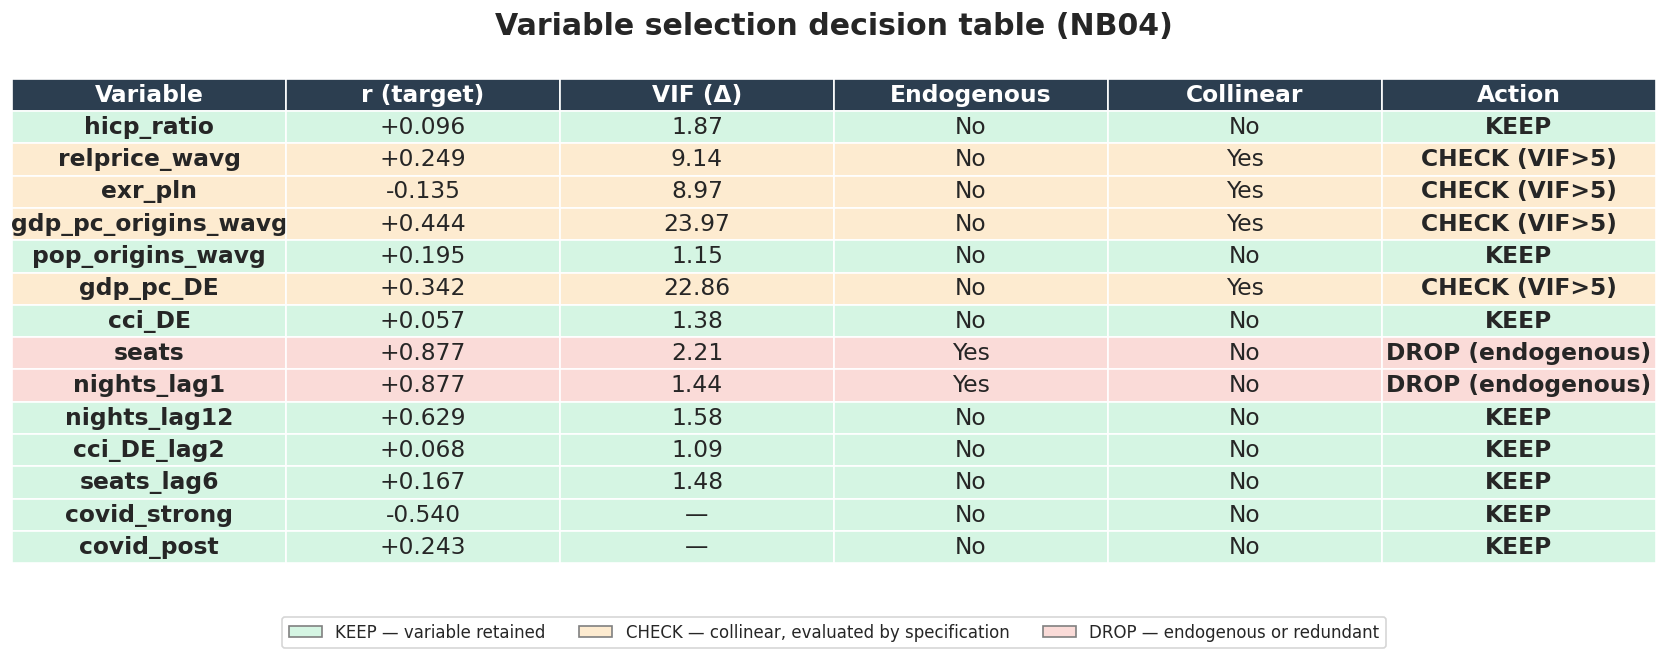

In [10]:
# --- BUILD VISUAL TABLE FIGURE ---
# Normalise column names and order
df = decision_df.copy()
df = df.rename(columns={
    'Variable': 'Variable',
    'r_with_target': 'r (target)',
    'VIF_diff': 'VIF (Δ)',
    'endogenous': 'Endogenous',
    'collinear': 'Collinear',
    'action': 'Action',
})

# Map action -> colour for the row background
def action_color(action):
    a = str(action).upper()
    if 'KEEP' in a:    return '#d5f5e3'   # light green
    if 'DROP' in a:    return '#fadbd8'   # light red
    if 'CHECK' in a:   return '#fdebd0'   # light amber
    return 'white'

# Format numerical columns
df_disp = df.copy()
df_disp['r (target)'] = df_disp['r (target)'].apply(
    lambda x: f'{x:+.3f}' if pd.notna(x) else '—')
df_disp['VIF (Δ)'] = df_disp['VIF (Δ)'].apply(
    lambda x: f'{x:.2f}' if pd.notna(x) else '—')
df_disp['Endogenous'] = df_disp['Endogenous'].apply(
    lambda x: 'Yes' if x else 'No')
df_disp['Collinear'] = df_disp['Collinear'].apply(
    lambda x: 'Yes' if x else 'No')

# Compute row colours based on action
row_colors = [action_color(a) for a in df['Action']]

# --- DRAW THE TABLE AS A FIGURE ---
fig, ax = plt.subplots(figsize=(14, 0.4 * len(df)))
ax.axis('off')

# Render with matplotlib's table API
n_rows, n_cols = df_disp.shape
table = ax.table(
    cellText=df_disp.values,
    colLabels=df_disp.columns,
    cellLoc='center', loc='center',
    cellColours=[[c] * n_cols for c in row_colors],
    colColours=[COLORS['primary']] * n_cols,
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 1.6)

# Style header (white text on dark blue)
for j in range(n_cols):
    cell = table[(0, j)]
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')

# Style data cells
for i in range(1, n_rows + 1):
    for j in range(n_cols):
        cell = table[(i, j)]
        cell.set_edgecolor('white')
        # Make the variable name and action columns bold
        if j == 0 or df_disp.columns[j] == 'Action':
            cell.set_text_props(fontweight='bold')

# Title
plt.title('Variable selection decision table (NB04)',
          fontweight='bold', fontsize=18, pad=15)

# Legend below the table
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#d5f5e3', edgecolor='gray', label='KEEP — variable retained'),
    Patch(facecolor='#fdebd0', edgecolor='gray', label='CHECK — collinear, evaluated by specification'),
    Patch(facecolor='#fadbd8', edgecolor='gray', label='DROP — endogenous or redundant'),
]
ax.legend(handles=legend_handles, loc='upper center',
          bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=True, fontsize=10)

plt.tight_layout()
savefig('fig_4_6_variable_selection.png')
plt.show()

---

## Figure 5.1 — Baseline Models Comparison on the Hold-Out

Comparative plot of the four classical baselines (Naive Seasonal, Holt-Winters, SARIMA, SARIMAX) evaluated on the last 12 months of the panel. Includes the actual observed series and the training-set tail to give the reader temporal context. The MAPE of each model is annotated inline. The pre-COVID SARIMA variants reported in NB05 as robustness checks are deliberately excluded here to keep the figure aligned with the four models discussed in the thesis text and listed in Table 5.1.

**Source:** forecasts exported by NB05 to `data/processed/baseline_forecasts.csv` and `data/processed/baseline_metrics.csv`.

In [11]:
# --- LOAD THE TARGET SERIES FROM THE MASTER PANEL ---
panel_path = os.path.join('..', '..', 'data', 'processed',
                           'master_panel_monthly.csv')
panel_5_1 = pd.read_csv(panel_path, index_col=0, parse_dates=True)
panel_5_1.index.name = 'date'

# Replicate the train/test split used in NB05 (last 12 months as hold-out)
TEST_MONTHS = 12
y_full = panel_5_1['nights'].dropna()
split_date = y_full.index[-TEST_MONTHS]
y_train = y_full[y_full.index < split_date]
y_test  = y_full[y_full.index >= split_date]

print(f'Target series: {len(y_full)} months '
      f'({y_full.index[0]:%Y-%m} -> {y_full.index[-1]:%Y-%m})')
print(f'Training:      {len(y_train)} months')
print(f'Test (hold-out): {len(y_test)} months '
      f'({y_test.index[0]:%Y-%m} -> {y_test.index[-1]:%Y-%m})')

# --- LOAD THE FORECASTS EXPORTED BY NB05 ---
# Expected file format: one row per month, one column per model.
# If your NB05 exported them differently, adapt the read_csv call below.
forecasts_path = os.path.join('..', '..', 'data', 'processed',
                              'baseline_forecasts.csv')
forecasts_df = pd.read_csv(forecasts_path, index_col=0, parse_dates=True)
forecasts_df.index.name = 'date'

print(f'\nForecasts loaded: {forecasts_df.shape}')
print(f'Columns: {list(forecasts_df.columns)}')

# --- LOAD THE METRICS EXPORTED BY NB05 (for the MAPE annotation) ---
metrics_path = os.path.join('..', '..', 'data', 'processed',
                            'baseline_metrics.csv')
metrics_df = pd.read_csv(metrics_path)
print(f'\nMetrics loaded:\n{metrics_df}')

Target series: 179 months (2011-01 -> 2025-11)
Training:      167 months
Test (hold-out): 12 months (2024-12 -> 2025-11)

Forecasts loaded: (12, 6)
Columns: ['Naive Seasonal', 'Holt-Winters', 'SARIMA', 'SARIMAX', 'SARIMA (pre-COVID)', 'SARIMA (pre-COVID corrected)']

Metrics loaded:
                                  Model      RMSE       MAE  MAPE
0                        Naive Seasonal 167403.63 149397.67  9.15
1                          Holt-Winters  92650.51  64078.19  3.86
2              SARIMA(1,1,1)(1,1,1)[12] 128826.01 106084.46  6.02
3             SARIMAX(1,1,1)(1,1,1)[12]  99867.19  88110.35  5.25
4               SARIMA (pre-COVID only) 341238.52 330729.23 21.31
5  SARIMA (pre-COVID + bias correction) 125869.94  96624.79  5.96


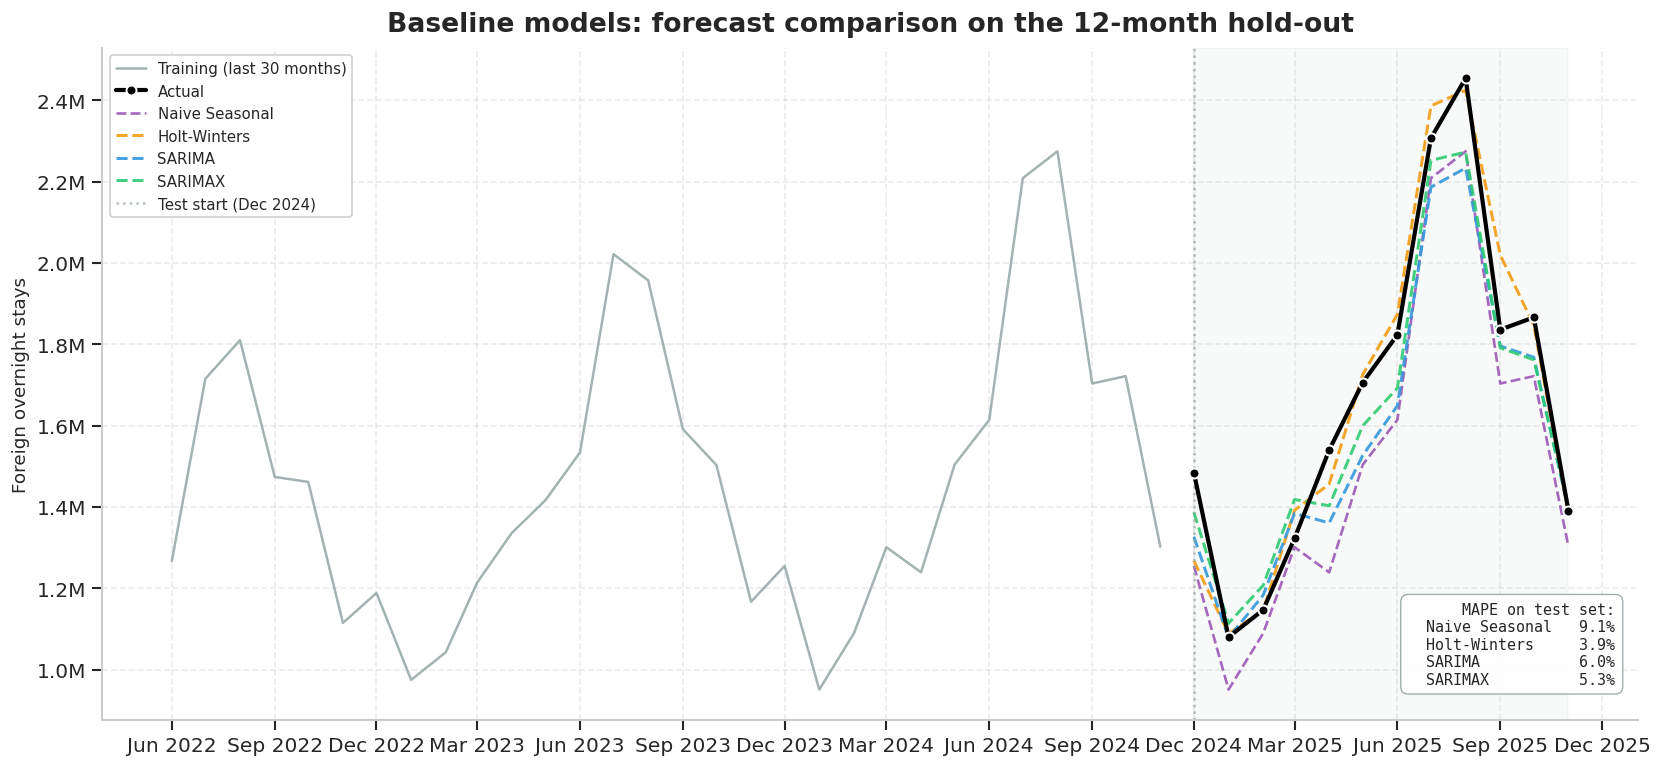

In [16]:
# --- FIGURE 5.1: BASELINE MODELS COMPARISON (THESIS VERSION) ---
fig, ax = plt.subplots(figsize=(14, 6.5))

# --- TRAINING TAIL (last 30 months for fuller seasonal context) ---
train_tail = y_train.iloc[-30:]
ax.plot(train_tail.index, train_tail.values,
        color=COLORS['gray'], lw=1.5, alpha=0.85,
        label='Training (last 30 months)')

# --- ACTUAL TEST SERIES ---
ax.plot(y_test.index, y_test.values,
        color='black', lw=2.5, marker='o', ms=6,
        markeredgecolor='white', markeredgewidth=1.2,
        label='Actual', zorder=10)

# --- BASELINE MODELS (only the four documented in the thesis) ---
# Pre-COVID SARIMA variants from NB05 are intentionally excluded here.
model_style = {
    'Naive Seasonal': dict(color=COLORS['accent4'], ls='--', lw=1.6),
    'Holt-Winters':   dict(color=COLORS['accent3'], ls='--', lw=1.8),
    'SARIMA':         dict(color=COLORS['accent1'], ls='--', lw=1.8),
    'SARIMAX':        dict(color=COLORS['accent2'], ls='--', lw=1.8),
}

documented_models = ['Naive Seasonal', 'Holt-Winters', 'SARIMA', 'SARIMAX']
for name in documented_models:
    if name in forecasts_df.columns:
        pred = forecasts_df[name].dropna()
        ax.plot(pred.index, pred.values,
                label=name, **model_style[name], alpha=0.9)
    else:
        print(f'WARNING: model "{name}" not found in forecasts_df.columns. '
              f'Check the column names in baseline_forecasts.csv.')

# --- TRAIN/TEST SPLIT MARKER WITH LABEL ---
ax.axvline(y_test.index[0], color=COLORS['gray'],
           ls=':', lw=1.5, alpha=0.7,
           label=f'Test start ({y_test.index[0]:%b %Y})')

# --- SUBTLE BACKGROUND TINT FOR THE TEST REGION ---
ax.axvspan(y_test.index[0], y_test.index[-1],
           color=COLORS['gray'], alpha=0.06, zorder=0)

# --- AXES FORMATTING ---
ax.set_title('Baseline models: forecast comparison on the 12-month hold-out',
              fontweight='bold', pad=10, fontsize=16)
ax.set_ylabel('Foreign overnight stays')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

ax.legend(loc='upper left', fontsize=9, frameon=True,
           framealpha=0.92, ncol=1)

# --- INLINE MAPE SUMMARY BOX (bottom-right) ---
# Read the MAPE values from the metrics dataframe loaded above. Adapt the
# column names ('Model', 'MAPE') if your NB05 export uses different ones.
mape_lines = ['MAPE on test set:']
for name in documented_models:
    # Try to match the model name flexibly against the metrics table
    match = metrics_df[metrics_df['Model'].str.contains(name,
                                                          case=False,
                                                          na=False)]
    if not match.empty:
        mape_val = match['MAPE'].iloc[0]
        mape_lines.append(f'  {name:<14s} {mape_val:>5.1f}%')

if len(mape_lines) > 1:
    ax.text(0.985, 0.05, '\n'.join(mape_lines),
            transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5',
                      facecolor='white', edgecolor=COLORS['gray'],
                      alpha=0.92, linewidth=0.8),
            family='monospace')

plt.tight_layout()
savefig('fig_5_1_baselines_holdout.png')
plt.show()

---

## Summary

All thesis-specific figures generated:

- `fig_1_1_tourism_gdp_share.png` — Tourism contribution to GDP by country (WTTC).
- `fig_1_2_pax_gdp_poland.png` — Air passengers vs GDP per capita relative to EU-27, Poland 2004–2024.
- `fig_2_1_origin_country_traffic.png` — Origin country composition of Polish air traffic, two panels.

The other figures of the thesis (4.3 to 5.8) are generated by the respective analysis notebooks (NB00–NB09) and should be exported from each of them following the naming convention used in the thesis manuscript.